# Day-1 Basics and Exploratory Data Analysis(EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

In [2]:
import os

# Method 1: Check if directory exists before changing to it
target_dir = r'C:\Users\grimm\healthcare__readmission'

if os.path.exists(target_dir):
    os.chdir(target_dir)
    print('Working from:', os.getcwd())
else:
    print(f"Directory '{target_dir}' does not exist.")
    # Option A: Create the directory if it doesn't exist
    os.makedirs(target_dir, exist_ok=True)
    os.chdir(target_dir)
    print('Created directory and working from:', os.getcwd())

Working from: C:\Users\grimm\healthcare__readmission


In [3]:
# Create a proper project folder and move there
project_path = r'C:\Users\grimm\healthcare__readmission'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

print('Now running from:', os.getcwd())
for folder in ['models', 'outputs/model_charts', 'outputs/eda_charts',
               'outputs/feature_charts', 'data/processed', 'data/raw']:
    os.makedirs(folder, exist_ok=True)
    print(f'  Created: {folder}/')
MODELS_DIR    = 'models'
CHARTS_DIR    = 'outputs/model_charts'
DATA_DIR      = 'data/processed'
PROCESSED_DIR = 'data/processed'
RANDOM_STATE  = 42
print('Paths fixed.')

Now running from: C:\Users\grimm\healthcare__readmission
  Created: models/
  Created: outputs/model_charts/
  Created: outputs/eda_charts/
  Created: outputs/feature_charts/
  Created: data/processed/
  Created: data/raw/
Paths fixed.


In [4]:
df = pd.read_csv('diabetic_data.csv')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
df.head(10)

Shape: 101,766 rows × 50 columns



,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
df.describe().round(2)

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,1.652016e+08,5.433040e+07,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,1.026403e+08,3.869636e+07,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.252200e+04,1.350000e+02,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,8.496119e+07,2.341322e+07,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,1.523890e+08,4.550514e+07,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,2.302709e+08,8.754595e+07,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,4.438672e+08,1.895026e+08,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


**Observations so far:**
- Most columns are categorical (object dtype) — they will need encoding later.
- `time_in_hospital`, `num_medications`, `num_lab_procedures` are numeric and will be key features.
- Write your own observations here as you explore.

In [7]:
# Target Variable: `readmitted`
print('Target variable distribution:')
print(df['readmitted'].value_counts())
print()
print('Percentage breakdown:')
print(df['readmitted'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Target variable distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Percentage breakdown:
readmitted
NO     53.91%
>30    34.93%
<30    11.16%
Name: proportion, dtype: object


In [8]:
#  Create binary target: <30 days = 1 (readmitted), everything else = 0 
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

pos_rate = df['readmitted_30'].mean() * 100
print(f'30-day readmission rate: {pos_rate:.2f}%')
print(f'Class imbalance ratio — Negative:Positive = {(100-pos_rate)/pos_rate:.1f}:1')

30-day readmission rate: 11.16%
Class imbalance ratio — Negative:Positive = 8.0:1


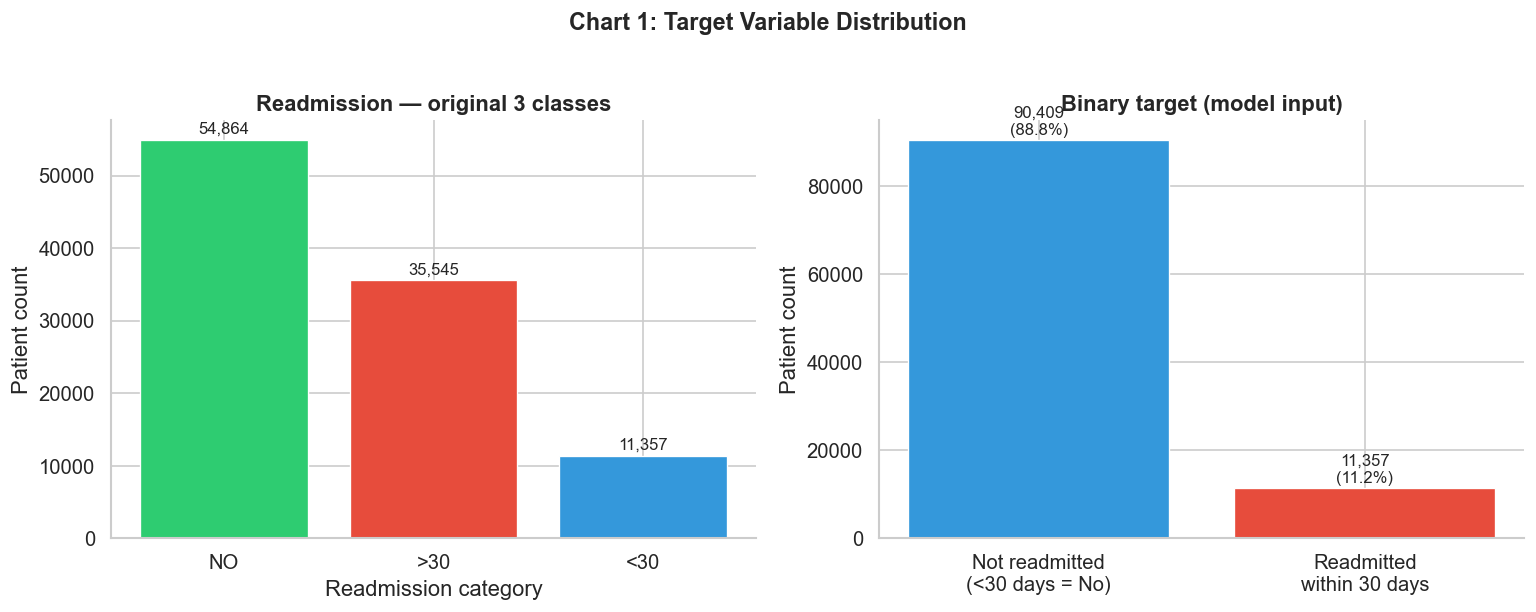

 Saved: 01_target_distribution.png


In [9]:
#  Chart 1: Target distribution (3-class + binary) 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: 3-class original
order = df['readmitted'].value_counts().index
counts = df['readmitted'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
bars = axes[0].bar(order, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Readmission — original 3 classes', fontweight='bold')
axes[0].set_xlabel('Readmission category')
axes[0].set_ylabel('Patient count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Right: binary target
binary_counts = df['readmitted_30'].value_counts().sort_index()
labels = ['Not readmitted\n(<30 days = No)', 'Readmitted\nwithin 30 days']
bar_colors = ['#3498db', '#e74c3c']
bars2 = axes[1].bar(labels, binary_counts.values, color=bar_colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Binary target (model input)', fontweight='bold')
axes[1].set_ylabel('Patient count')
for bar, val in zip(bars2, binary_counts.values):
    pct = val / len(df) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.suptitle('Chart 1: Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/01_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: 01_target_distribution.png')

**Key finding:** The dataset is heavily imbalanced — only ~11% of patients were readmitted within 30 days. We will handle this using SMOTE oversampling in (modelling phase).

In [10]:
# Missing Values
#  Replace '?' with NaN so we can count missing values properly 
df_missing = df.replace('?', np.nan)

# Count missing per column, filter to columns that have ANY missing
missing = df_missing.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
print()
print(missing_df.to_string())

Columns with missing values: 9

                   missing_count  missing_pct
weight                     98569        96.86
max_glu_serum              96420        94.75
A1Cresult                  84748        83.28
medical_specialty          49949        49.08
payer_code                 40256        39.56
race                        2273         2.23
diag_3                      1423         1.40
diag_2                       358         0.35
diag_1                        21         0.02


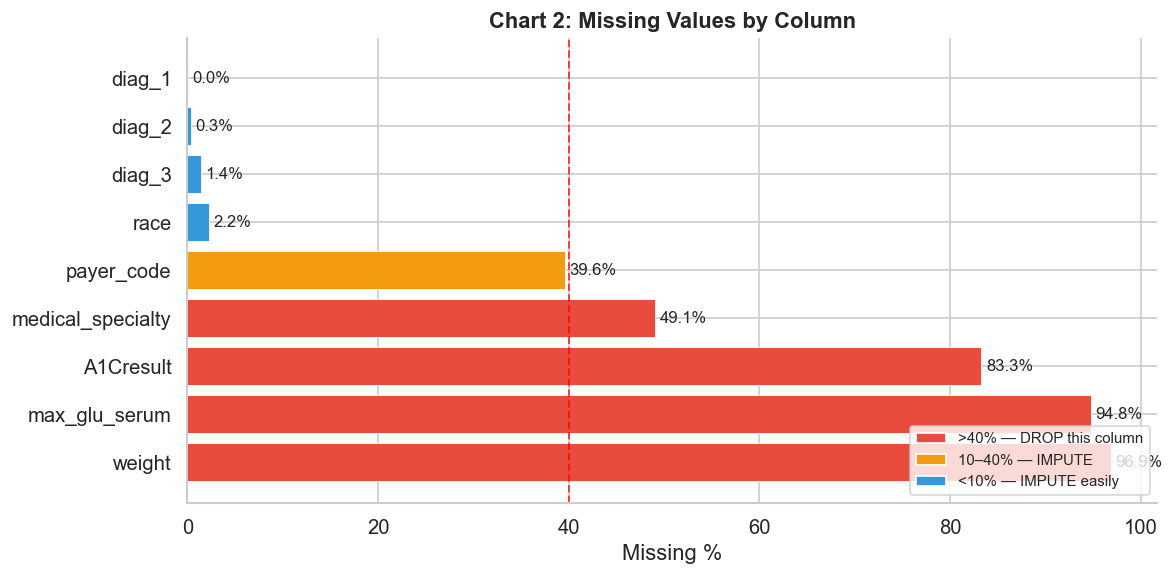

 Saved: 02_missing_values.png


In [11]:
#  Chart 2: Missing values heatmap 
fig, ax = plt.subplots(figsize=(10, 5))

colors_miss = ['#e74c3c' if p > 40 else '#f39c12' if p > 10 else '#3498db'
               for p in missing_df['missing_pct'].values]

bars = ax.barh(missing_df.index, missing_df['missing_pct'], color=colors_miss,
               edgecolor='white', linewidth=0.5)

# Add percentage labels
for bar, pct in zip(bars, missing_df['missing_pct'].values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=10)

# Add threshold lines
ax.axvline(x=40, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='40% threshold (drop)')
ax.set_xlabel('Missing %')
ax.set_title('Chart 2: Missing Values by Column', fontweight='bold')
ax.legend(fontsize=9)

# Color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='>40% — DROP this column'),
    Patch(facecolor='#f39c12', label='10–40% — IMPUTE'),
    Patch(facecolor='#3498db', label='<10% — IMPUTE easily'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/02_missing_values.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: 02_missing_values.png')

**Key finding:** 
`weight` (~97%),    `payer_code` (~40%), and `medical_specialty` (~49%) have too many missing values. 
We will **drop** these columns in  (preprocessing). The rest can be imputed.

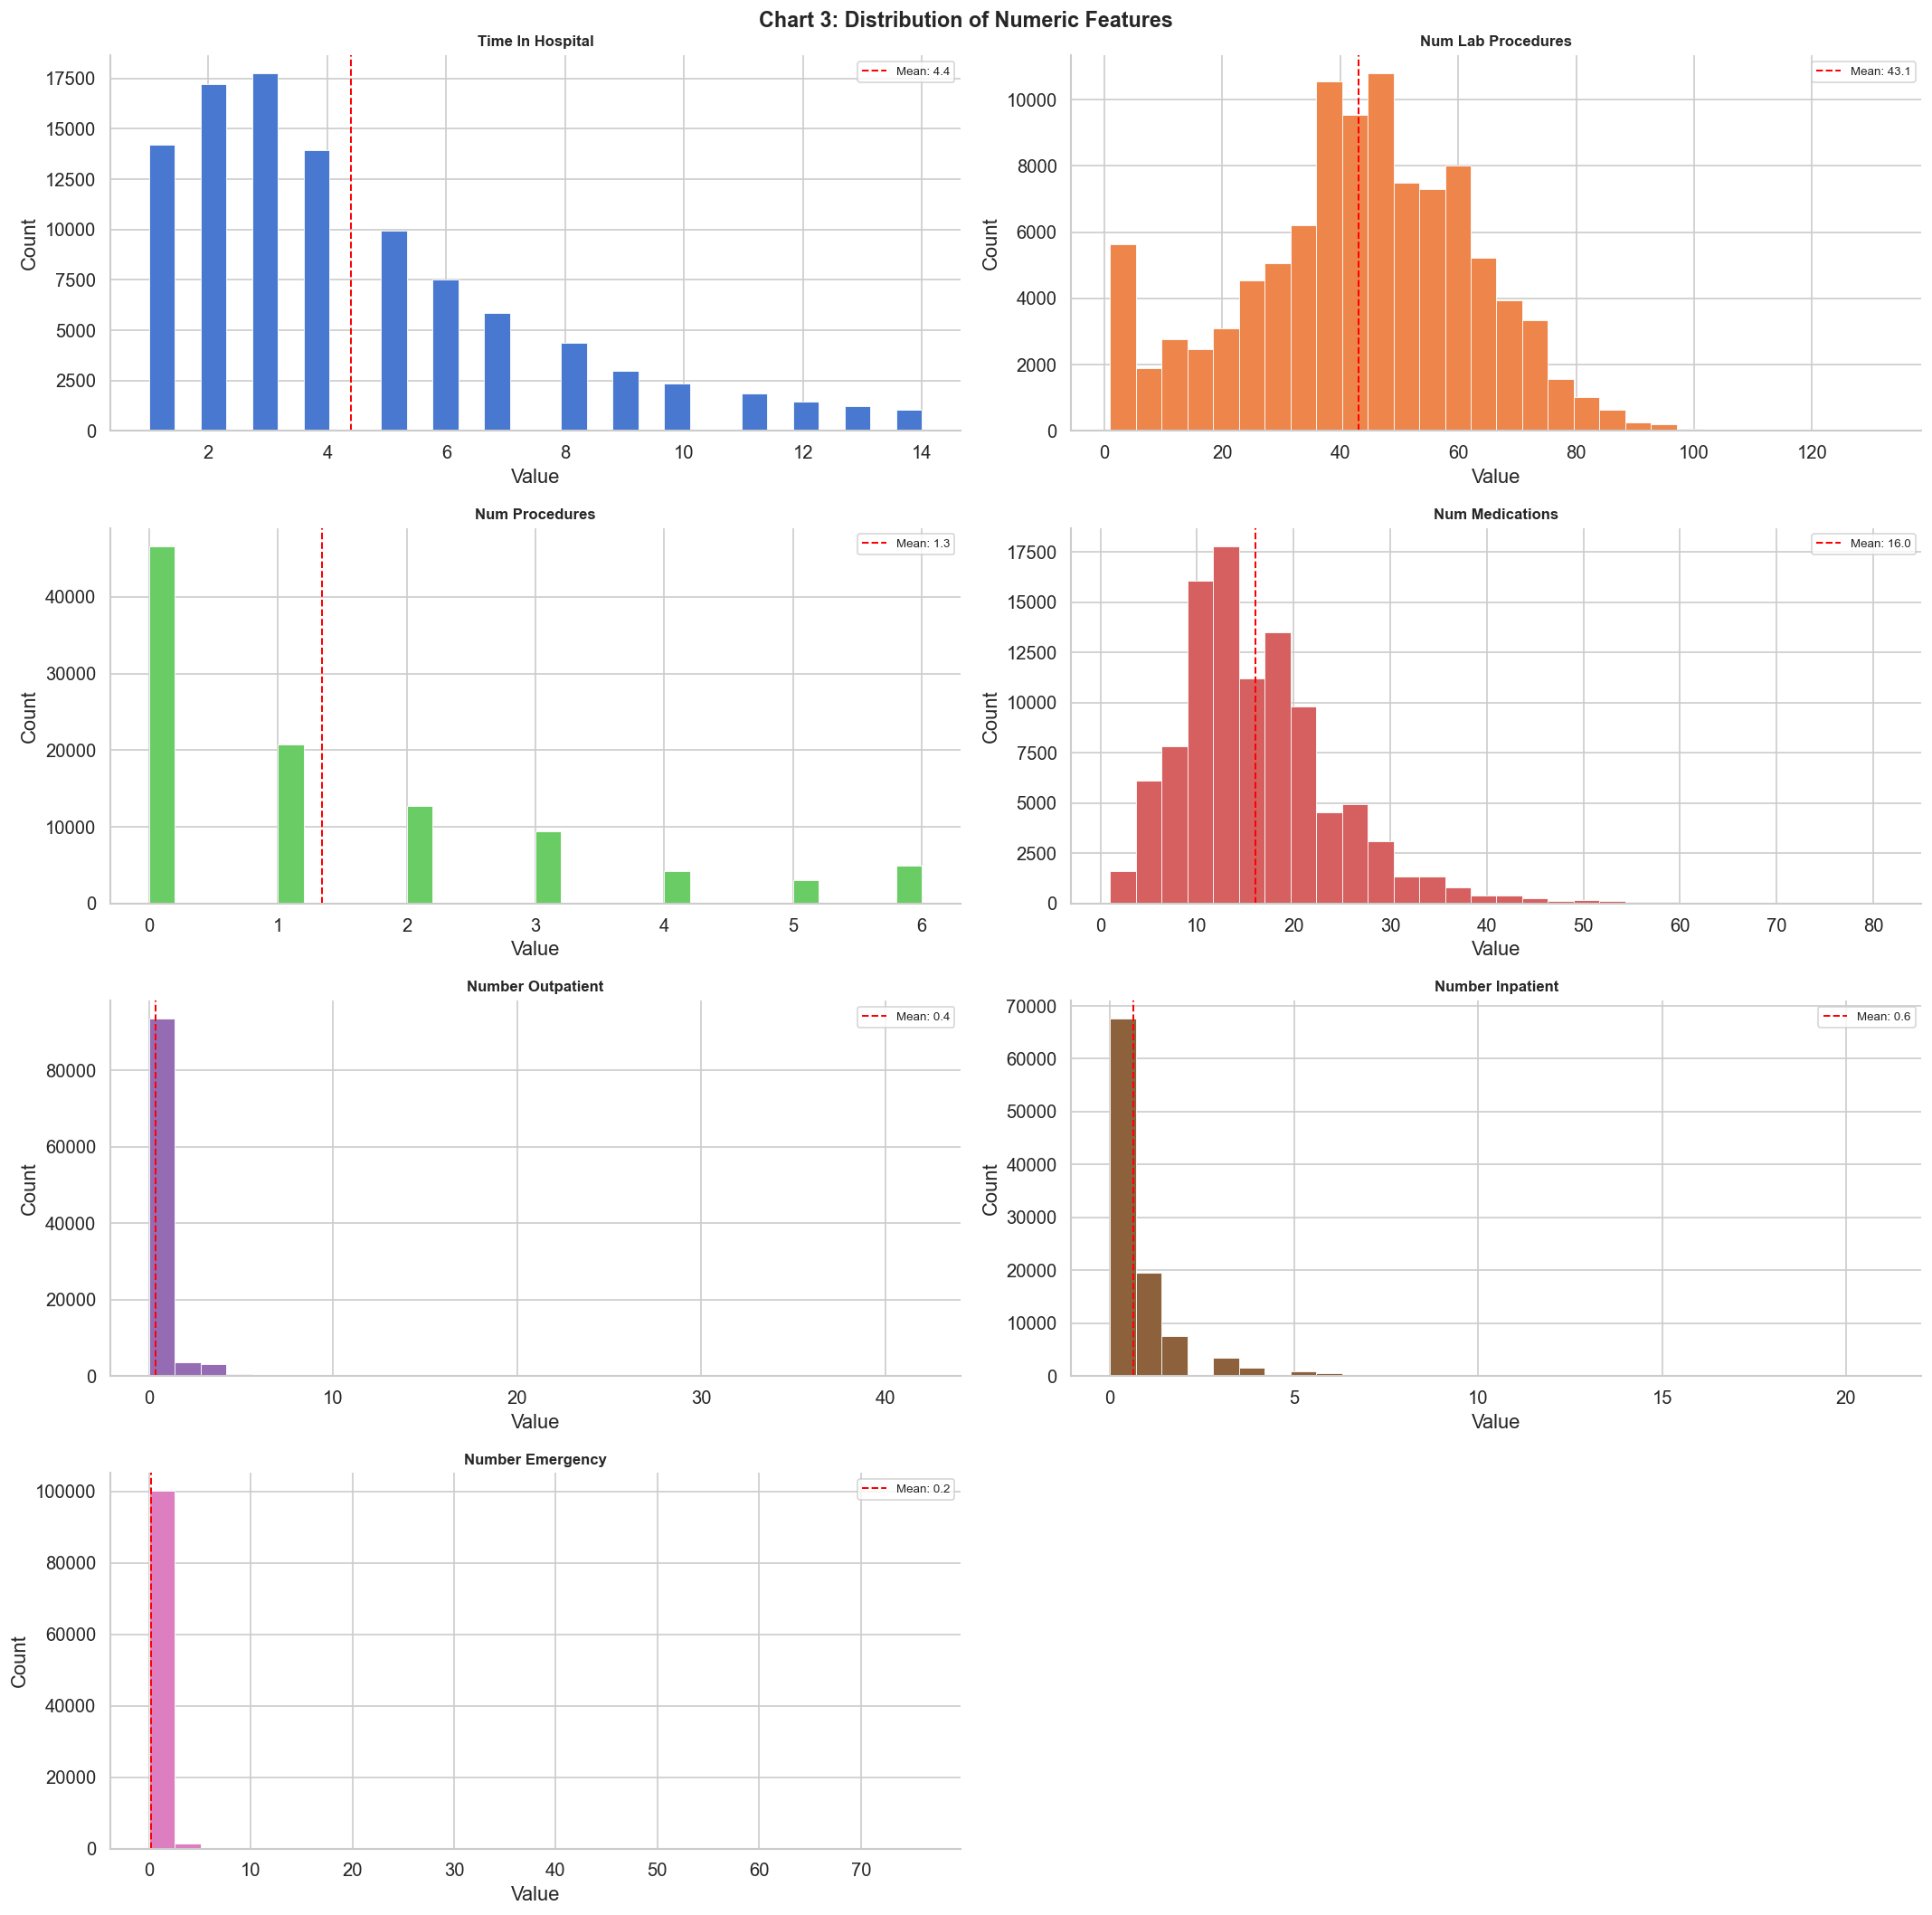

 Saved: 03_numeric_distributions.png


In [12]:
# Numeric Feature Distributions
#  Chart 3: Distribution of key numeric features 
numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_inpatient', 'number_emergency'
]

fig, axes = plt.subplots(4, 2, figsize=(18, 18))
axes = axes.flatten()

palette = sns.color_palette('muted', len(numeric_cols))

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color=palette[i], edgecolor='white', linewidth=0.5)
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

# Hide the unused last subplot
axes[-1].set_visible(False)

plt.suptitle('Chart 3: Distribution of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/03_numeric_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: 03_numeric_distributions.png')

**Key findings:**
- `time_in_hospital` is roughly uniform between 1–14 days.
- `num_medications` has a roughly normal distribution centred around 15.
- `number_inpatient`, `number_outpatient`, `number_emergency` are highly right-skewed — most patients have 0 prior visits, but a small group has many. This skewed group is likely high-risk.

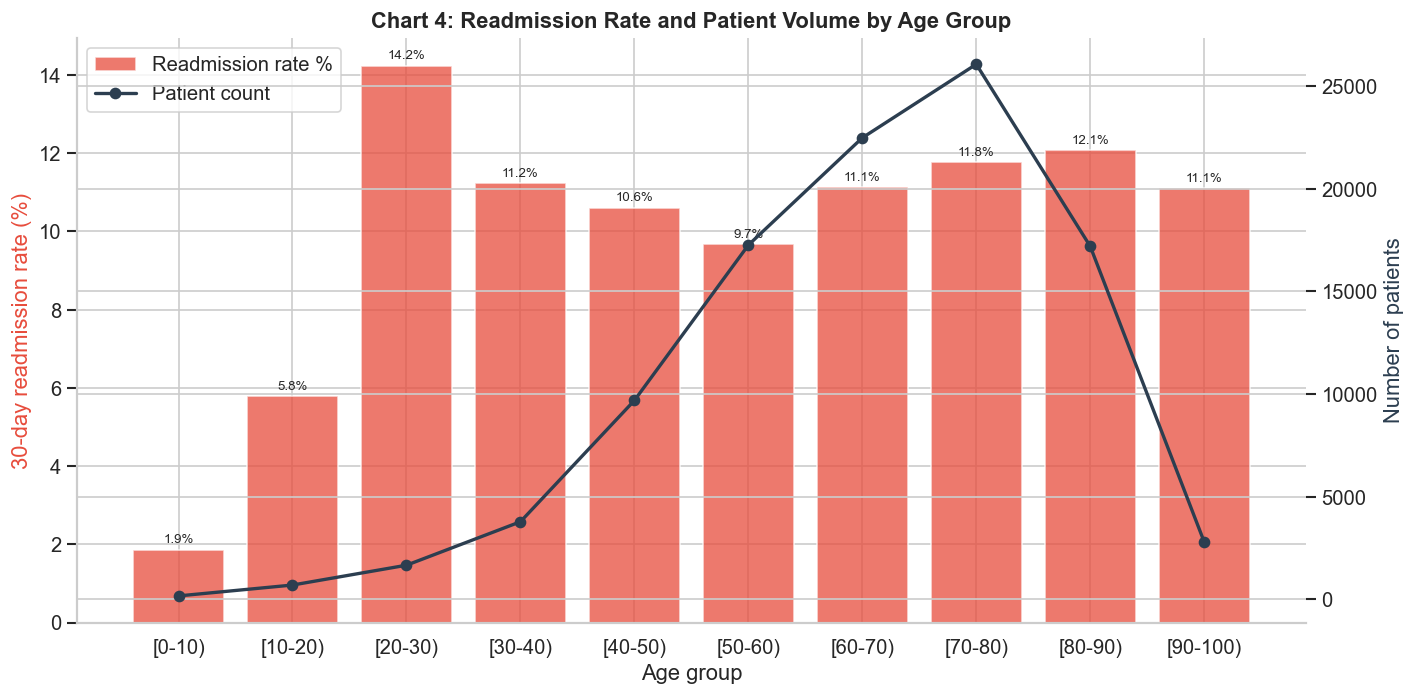

 Saved: 04_readmission_by_age.png


In [13]:
# Readmission Rate by Age Group
#  Chart 4: Readmission rate by age 
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_readmit = df.groupby('age')['readmitted_30'].agg(['mean', 'count']).reset_index()
age_readmit['mean_pct'] = age_readmit['mean'] * 100
# Reorder by age
age_readmit['age'] = pd.Categorical(age_readmit['age'], categories=age_order, ordered=True)
age_readmit = age_readmit.sort_values('age')

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Bar: readmission rate
bars = ax1.bar(age_readmit['age'], age_readmit['mean_pct'],
               color='#e74c3c', alpha=0.75, edgecolor='white', label='Readmission rate %')

# Line: patient count
ax2.plot(age_readmit['age'], age_readmit['count'], color='#2c3e50',
         marker='o', linewidth=2, markersize=6, label='Patient count')

ax1.set_xlabel('Age group')
ax1.set_ylabel('30-day readmission rate (%)', color='#e74c3c')
ax2.set_ylabel('Number of patients', color='#2c3e50')
ax1.set_title('Chart 4: Readmission Rate and Patient Volume by Age Group', fontweight='bold')
plt.xticks(rotation=30)

# Add value labels on bars
for bar, val in zip(bars, age_readmit['mean_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/04_readmission_by_age.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: 04_readmission_by_age.png')

**Key finding:** Readmission rate is fairly consistent across middle-age groups (11–13%) but slightly higher in very young and very old patients. The 70–90 age bracket has the highest patient volume AND elevated readmission risk — these are the highest-priority patients for early intervention programmes.

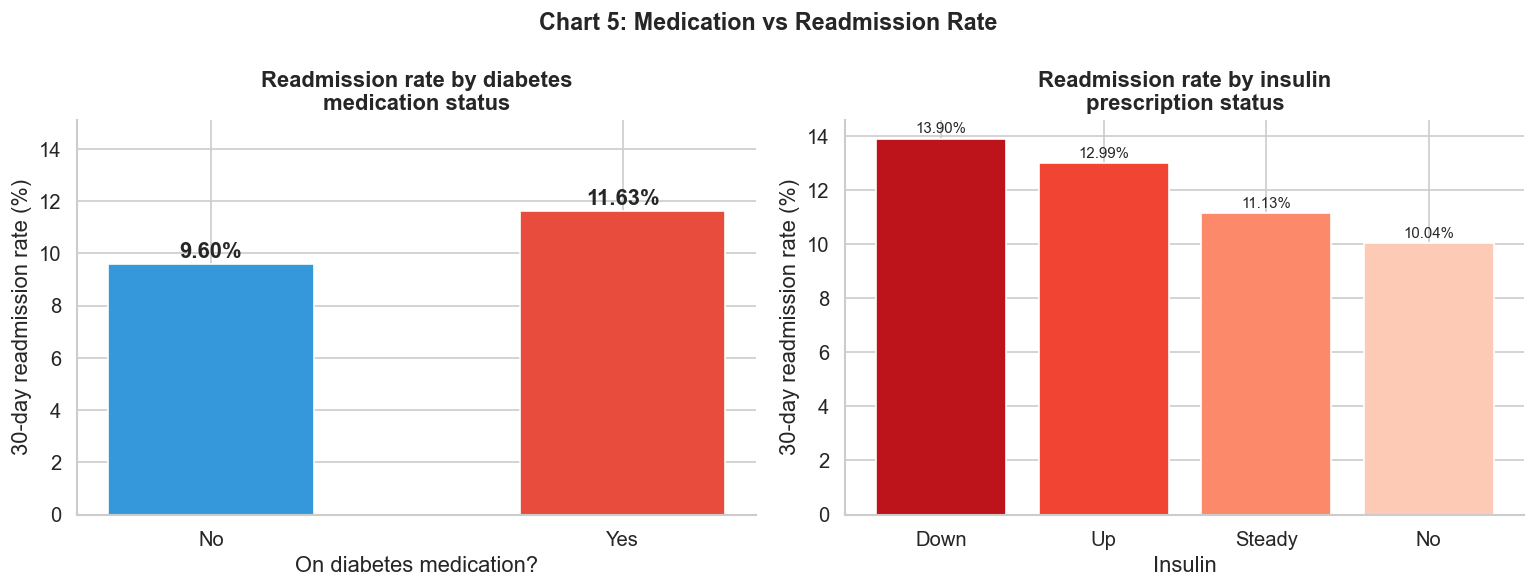

 Saved: 05_medication_readmission.png


In [14]:
# Readmission Rate by Diabetes Medication
#  Chart 5: Readmission by diabetesMed (Yes/No)
med_readmit = df.groupby('diabetesMed')['readmitted_30'].agg(['mean', 'count']).reset_index()
med_readmit['mean_pct'] = med_readmit['mean'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: readmission rate comparison
colors_med = ['#3498db', '#e74c3c']
bars = axes[0].bar(med_readmit['diabetesMed'], med_readmit['mean_pct'],
                   color=colors_med, edgecolor='white', width=0.5)
axes[0].set_title('Readmission rate by diabetes\nmedication status', fontweight='bold')
axes[0].set_xlabel('On diabetes medication?')
axes[0].set_ylabel('30-day readmission rate (%)')
axes[0].set_ylim(0, max(med_readmit['mean_pct']) * 1.3)
for bar, val in zip(bars, med_readmit['mean_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

# Right: readmission rate by insulin change
insulin_readmit = df.groupby('insulin')['readmitted_30'].mean().mul(100).sort_values(ascending=False)
bars2 = axes[1].bar(insulin_readmit.index, insulin_readmit.values,
                    color=sns.color_palette('Reds_r', len(insulin_readmit)),
                    edgecolor='white')
axes[1].set_title('Readmission rate by insulin\nprescription status', fontweight='bold')
axes[1].set_xlabel('Insulin')
axes[1].set_ylabel('30-day readmission rate (%)')
for bar, val in zip(bars2, insulin_readmit.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Chart 5: Medication vs Readmission Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/05_medication_readmission.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: 05_medication_readmission.png')

**Key finding:** Patients ON diabetes medication have a higher 30-day readmission rate than those not on medication. This is likely because medicated patients have more severe diabetes — severity drives both the medication need AND the readmission risk.

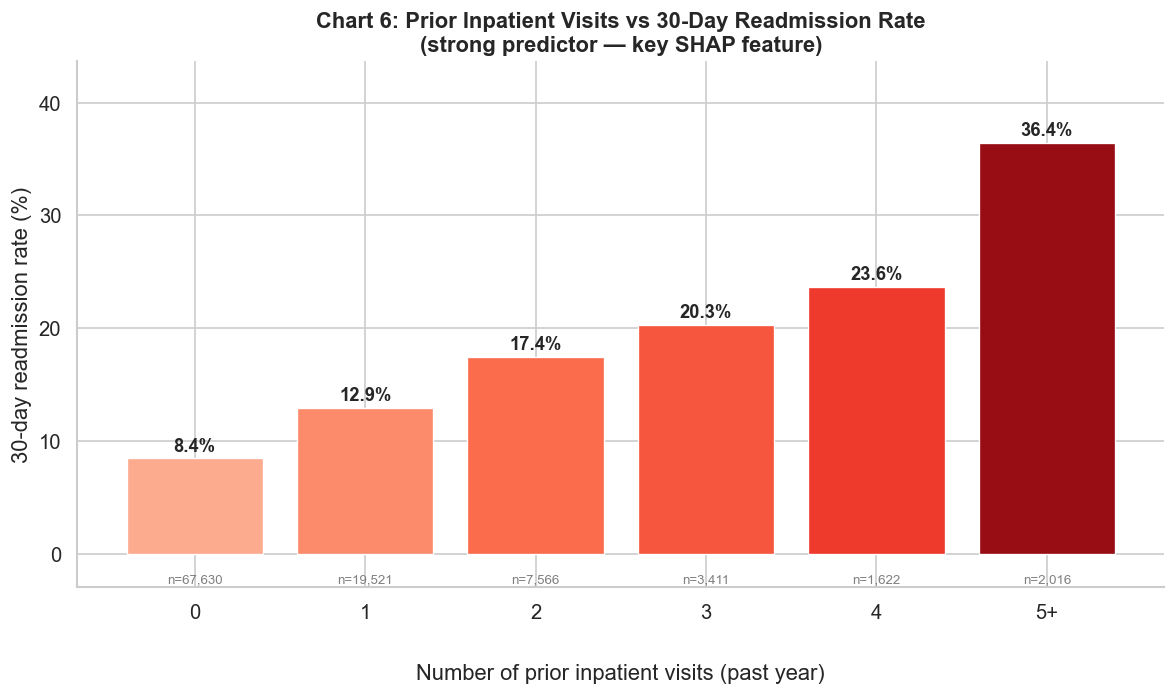

Saved: 06_inpatient_visits_readmission.png


In [15]:
# Readmission Rate by Number of Prior Inpatient Visits
#  Chart 6: Prior inpatient visits vs readmission 
# Cap at 5+ to avoid tiny groups
df['inpatient_capped'] = df['number_inpatient'].clip(upper=5)
ip_readmit = df.groupby('inpatient_capped')['readmitted_30'].agg(['mean', 'count']).reset_index()
ip_readmit['mean_pct'] = ip_readmit['mean'] * 100
ip_readmit['label'] = ip_readmit['inpatient_capped'].apply(
    lambda x: f'{int(x)}+' if x == 5 else str(int(x))
)

fig, ax = plt.subplots(figsize=(10, 6))

# Color gradient: more visits = darker red
cmap = plt.cm.get_cmap('Reds')
norm_vals = (ip_readmit['mean_pct'] - ip_readmit['mean_pct'].min()) / \
            (ip_readmit['mean_pct'].max() - ip_readmit['mean_pct'].min())
bar_colors = [cmap(0.3 + 0.6 * v) for v in norm_vals]

bars = ax.bar(ip_readmit['label'], ip_readmit['mean_pct'],
              color=bar_colors, edgecolor='white', linewidth=0.8)

# Patient count annotation below x-axis
for bar, (_, row) in zip(bars, ip_readmit.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{row["mean_pct"]:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.text(bar.get_x() + bar.get_width()/2, -1.8,
            f'n={row["count"]:,}', ha='center', va='top', fontsize=8, color='gray')
ax.set_xlabel('Number of prior inpatient visits (past year)', labelpad=25)
ax.set_ylabel('30-day readmission rate (%)')
ax.set_title('Chart 6: Prior Inpatient Visits vs 30-Day Readmission Rate\n'
             '(strong predictor — key SHAP feature)', fontweight='bold')
ax.set_ylim(-3, ip_readmit['mean_pct'].max() * 1.2)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/06_inpatient_visits_readmission.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 06_inpatient_visits_readmission.png')

**Key finding (strongest predictor):** Patients with 5+ prior inpatient visits have ~3× the readmission rate compared to first-time inpatients. This variable will show up as the top SHAP feature. In a clinical setting, this directly identifies high-risk patients for discharge support programmes.

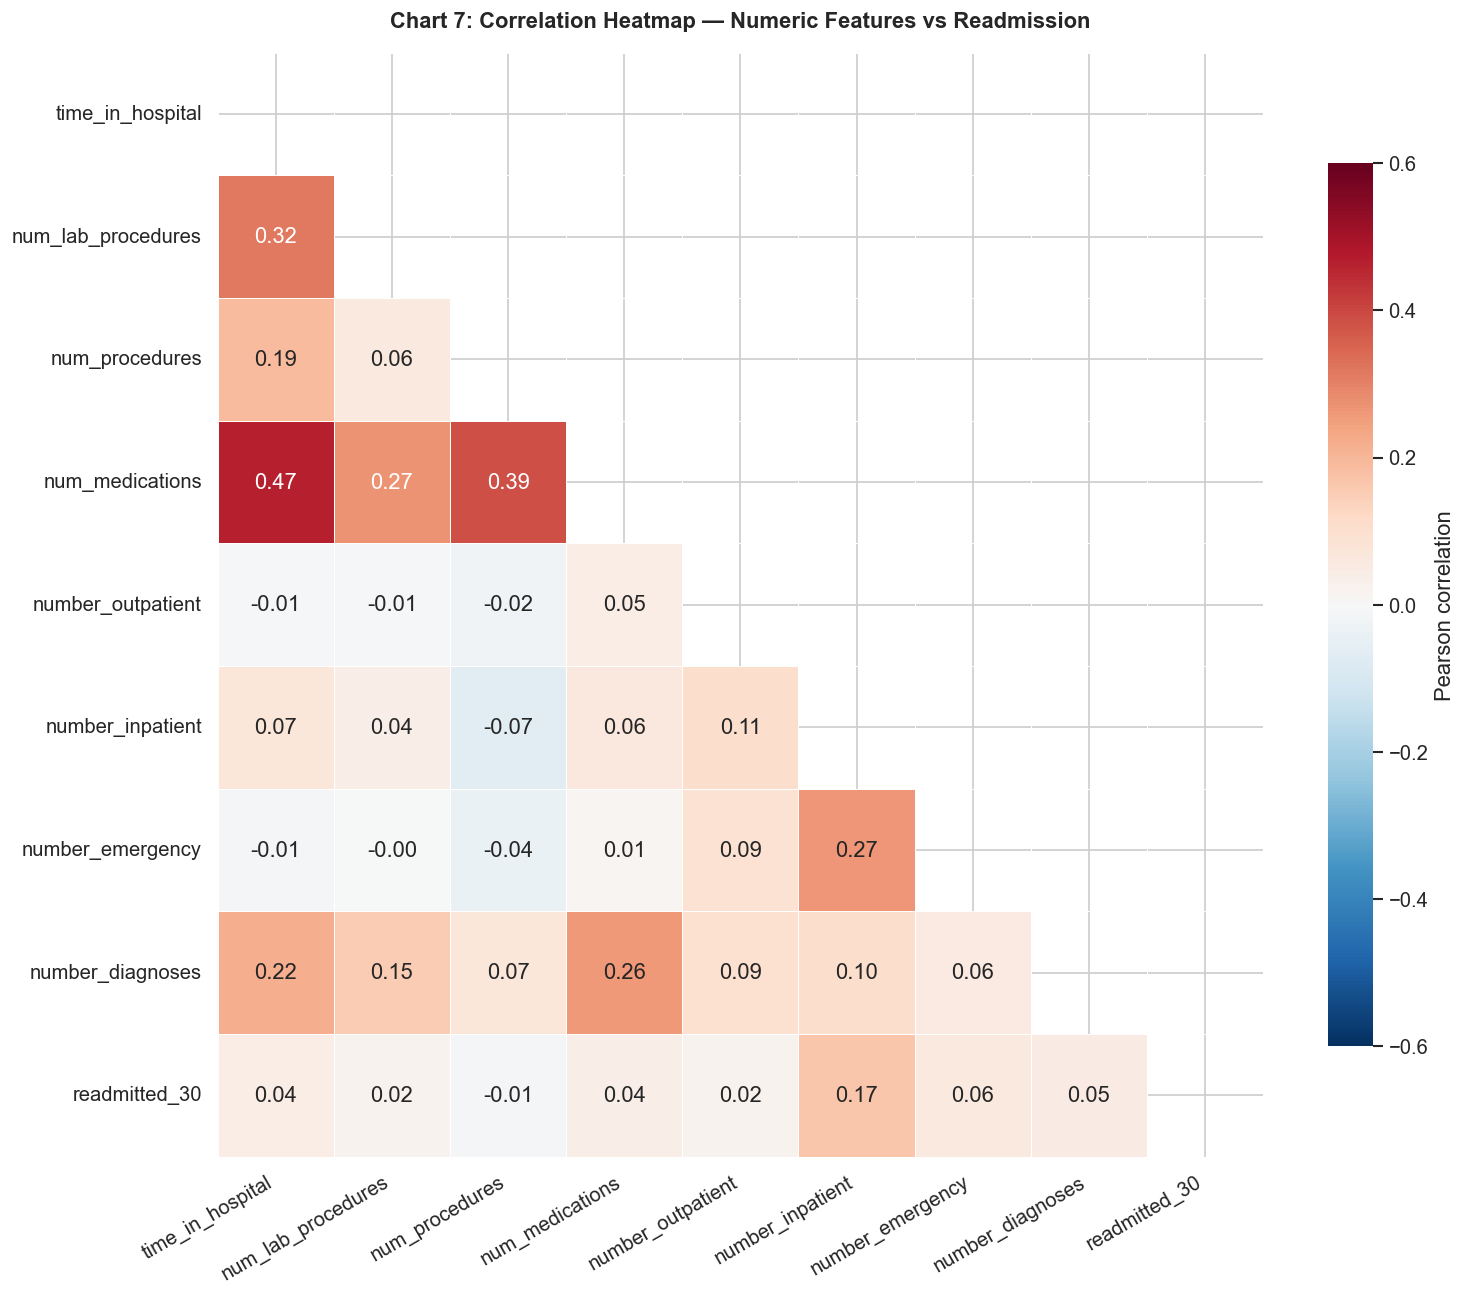

 Saved: 07_correlation_heatmap.png


In [16]:
# Correlation Heatmap (Numeric Features)
#  Chart 7: Correlation heatmap 
corr_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_inpatient',
    'number_emergency', 'number_diagnoses', 'readmitted_30'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-0.6, vmax=0.6,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson correlation'}
)

ax.set_title('Chart 7: Correlation Heatmap — Numeric Features vs Readmission',
             fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/07_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: 07_correlation_heatmap.png')

**Key findings from correlation:**
- `number_inpatient` has the highest correlation with `readmitted_30` — confirms our finding from Chart 6.
- `num_medications` and `time_in_hospital` are moderately correlated with each other (sicker patients stay longer and receive more drugs).
- Most correlations with the target are weak — XGBoost will capture non-linear relationships better than correlation suggests.

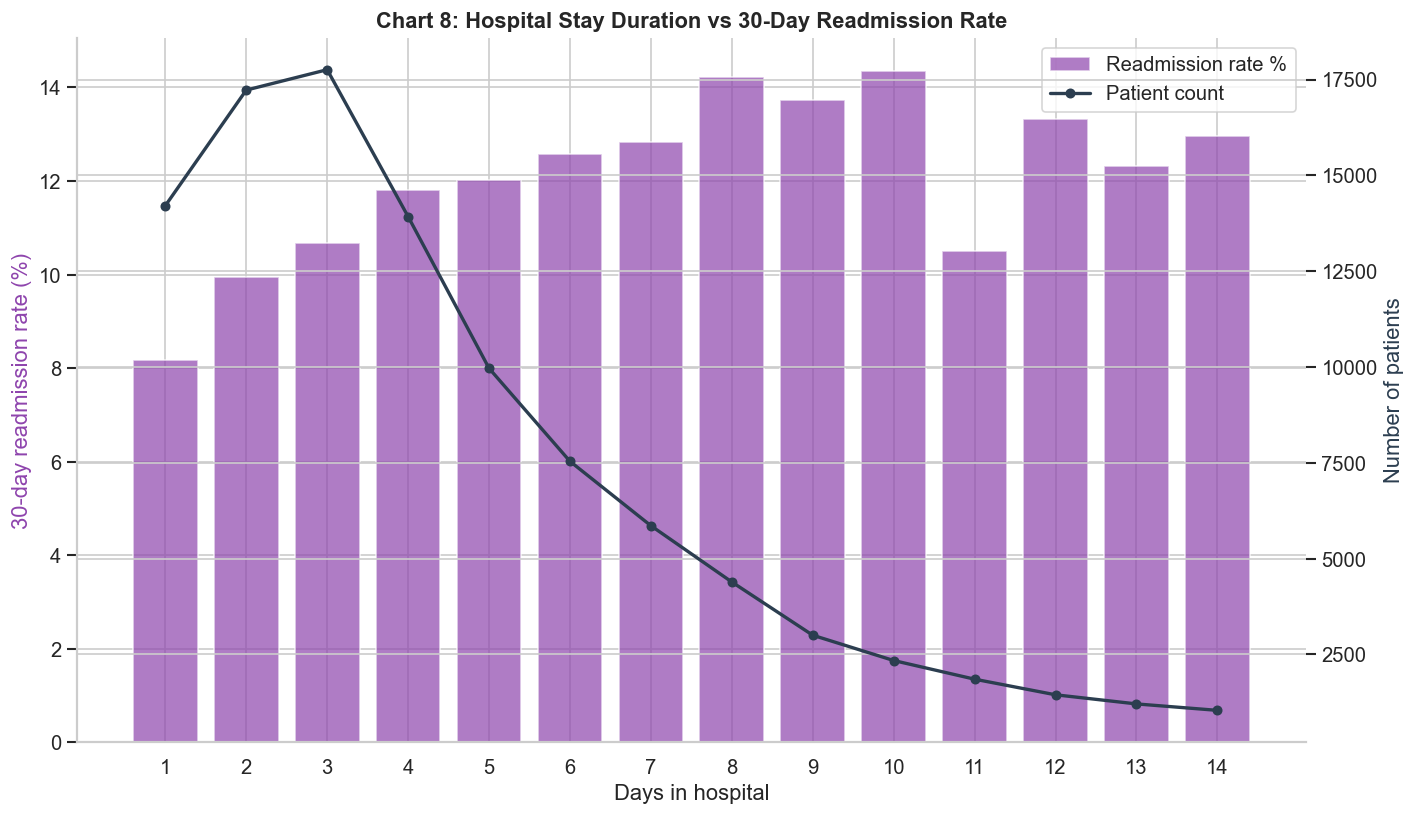

 Saved: 08_time_in_hospital_readmission.png


In [17]:
# Readmission Rate by Time in Hospital
#  Chart 8: Time in hospital vs readmission 
time_readmit = df.groupby('time_in_hospital')['readmitted_30'].agg(['mean', 'count']).reset_index()
time_readmit['mean_pct'] = time_readmit['mean'] * 100

fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

ax1.bar(time_readmit['time_in_hospital'], time_readmit['mean_pct'],
        color='#8e44ad', alpha=0.7, edgecolor='white', label='Readmission rate %')
ax2.plot(time_readmit['time_in_hospital'], time_readmit['count'],
         color='#2c3e50', marker='o', linewidth=2, markersize=5, label='Patient count')

ax1.set_xlabel('Days in hospital')
ax1.set_ylabel('30-day readmission rate (%)', color='#8e44ad')
ax2.set_ylabel('Number of patients', color='#2c3e50')
ax1.set_title('Chart 8: Hospital Stay Duration vs 30-Day Readmission Rate', fontweight='bold')
ax1.set_xticks(range(1, 15))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/08_time_in_hospital_readmission.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: 08_time_in_hospital_readmission.png')

In [18]:
# Top Categorical Features — Unique Value Counts
#  Understand cardinality of categorical columns 
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['readmitted', 'encounter_id']]

cardinality = pd.DataFrame({
    'column': cat_cols,
    'unique_values': [df[c].nunique() for c in cat_cols]
}).sort_values('unique_values', ascending=False)

print('Cardinality of categorical columns:')
print(cardinality.to_string(index=False))
print()
print('HIGH cardinality (>20 unique) — need grouping or target encoding:')
print(cardinality[cardinality['unique_values'] > 20]['column'].tolist())

Cardinality of categorical columns:
                  column  unique_values
                  diag_3            790
                  diag_2            749
                  diag_1            717
       medical_specialty             73
              payer_code             18
                     age             10
                  weight             10
                    race              6
               glipizide              4
     glyburide-metformin              4
                 insulin              4
                miglitol              4
                acarbose              4
           rosiglitazone              4
            pioglitazone              4
               glyburide              4
          chlorpropamide              4
             nateglinide              4
             repaglinide              4
               metformin              4
             glimepiride              4
                  gender              3
              tolazamide              3
    

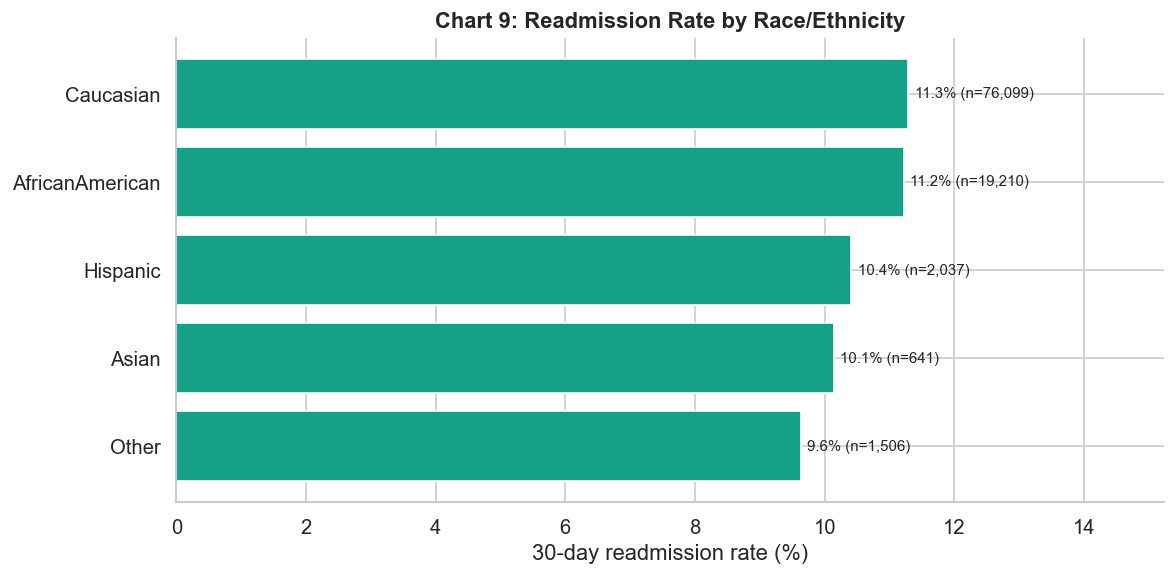

 Saved: 09_readmission_by_race.png


In [19]:
# Chart 9: Readmission rate by race 
df_clean_race = df[df['race'] != '?'].copy()
race_readmit = df_clean_race.groupby('race')['readmitted_30'].agg(['mean', 'count']).reset_index()
race_readmit['mean_pct'] = race_readmit['mean'] * 100
race_readmit = race_readmit.sort_values('mean_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(race_readmit['race'], race_readmit['mean_pct'],
               color='#16a085', edgecolor='white')
for bar, (_, row) in zip(bars, race_readmit.iterrows()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{row['mean_pct']:.1f}% (n={row['count']:,})",
            va='center', fontsize=9)
ax.set_xlabel('30-day readmission rate (%)')
ax.set_title('Chart 9: Readmission Rate by Race/Ethnicity', fontweight='bold')
ax.set_xlim(0, race_readmit['mean_pct'].max() * 1.35)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/09_readmission_by_race.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: 09_readmission_by_race.png')

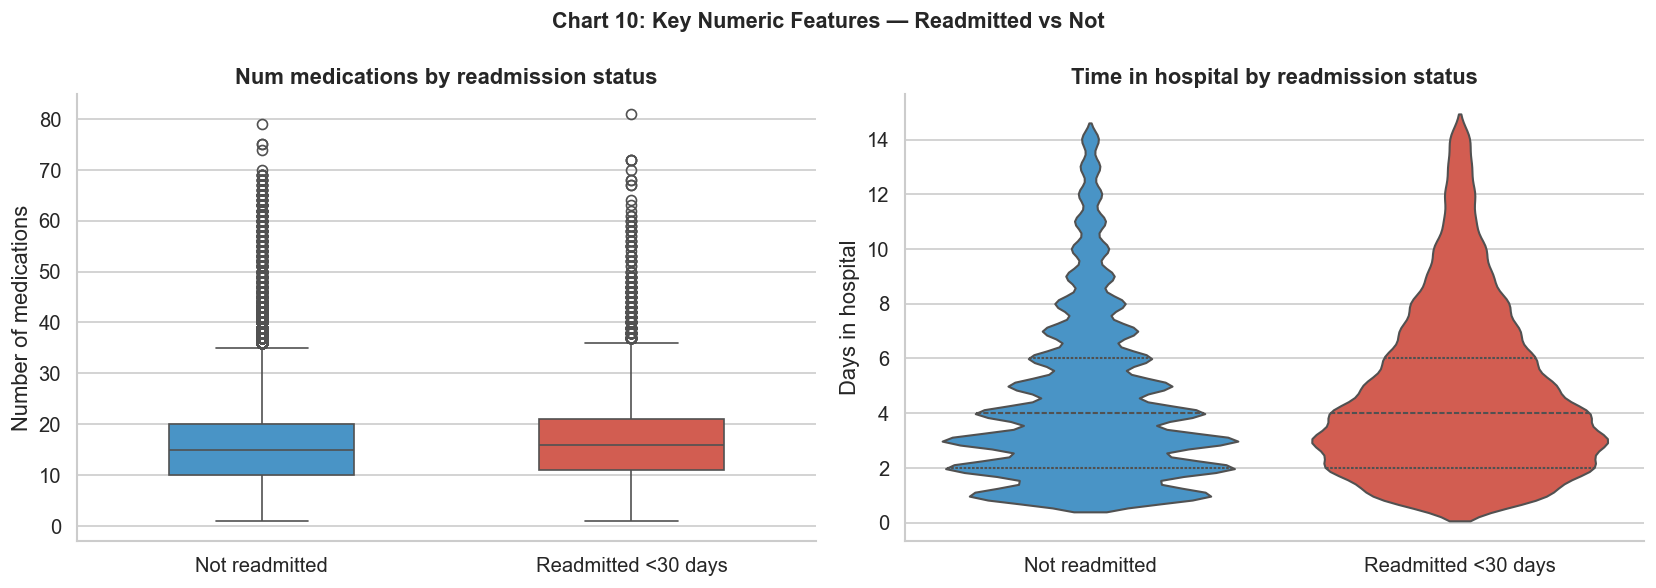

 Saved: 10_boxplot_readmission.png


In [20]:
# Number of Medications vs Readmission (Boxplot)
#  Chart 10: Medications distribution for readmitted vs not 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df['readmitted_label'] = df['readmitted_30'].map({0: 'Not readmitted', 1: 'Readmitted <30 days'})
sns.boxplot(
    data=df, x='readmitted_label', y='num_medications',
    palette=['#3498db', '#e74c3c'], ax=axes[0], width=0.5
)
axes[0].set_title('Num medications by readmission status', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of medications')

# Violin
sns.violinplot(
    data=df, x='readmitted_label', y='time_in_hospital',
    palette=['#3498db', '#e74c3c'], ax=axes[1], inner='quartile'
)
axes[1].set_title('Time in hospital by readmission status', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Days in hospital')

plt.suptitle('Chart 10: Key Numeric Features — Readmitted vs Not', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/10_boxplot_readmission.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: 10_boxplot_readmission.png')

# EDA Summary — Key Findings

In [21]:
print('=' * 65)
print('  EDA SUMMARY — Healthcare Readmission Project')
print('=' * 65)
print()
print(f'  Dataset size       : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Readmission rate   : {df["readmitted_30"].mean()*100:.2f}% (class imbalance!)')
print(f'  Missing >40%       : weight, payer_code, medical_specialty → DROP')
print(f'  Missing <40%       : race (~2%), diag columns → IMPUTE')
print()
print('  TOP PREDICTORS (identified from EDA):')
print('  1. number_inpatient  — prior inpatient visits (strongest)')
print('  2. num_medications   — number of meds prescribed')
print('  3. number_emergency  — prior emergency visits')
print('  4. time_in_hospital  — length of current stay')
print('  5. number_diagnoses  — comorbidity count')
print()
print('  NEXT STEPS (Day 2):')
print('  → Drop high-missing columns')
print('  → Remove deceased/hospice patients')
print('  → One encounter per patient (deduplication)')
print('  → Create binary target variable')
print()

  EDA SUMMARY — Healthcare Readmission Project

  Dataset size       : 101,766 rows × 53 columns
  Readmission rate   : 11.16% (class imbalance!)
  Missing >40%       : weight, payer_code, medical_specialty → DROP
  Missing <40%       : race (~2%), diag columns → IMPUTE

  TOP PREDICTORS (identified from EDA):
  1. number_inpatient  — prior inpatient visits (strongest)
  2. num_medications   — number of meds prescribed
  3. number_emergency  — prior emergency visits
  4. time_in_hospital  — length of current stay
  5. number_diagnoses  — comorbidity count

  NEXT STEPS (Day 2):
  → Drop high-missing columns
  → Remove deceased/hospice patients
  → One encounter per patient (deduplication)
  → Create binary target variable



#  Day 2: Data Cleaning & Preprocessing

# Step 1 — Replace '?' with NaN
 
 **Why:** The dataset encodes missing values as `'?'` strings instead of `NaN`. pandas cannot detect these as missing unless we convert them first.

In [22]:
# Count '?' before replacement
question_marks = (df == '?').sum().sum()
print(f'Total "?" values in dataset before replacement: {question_marks:,}')
print()
print('Columns containing "?":')
cols_with_q = [(col, (df[col] == '?').sum()) for col in df.columns if (df[col] == '?').sum() > 0]
for col, count in sorted(cols_with_q, key=lambda x: -x[1]):
    pct = count / len(df) * 100
    print(f'  {col:<30} {count:>7,}  ({pct:.1f}%)')

Total "?" values in dataset before replacement: 192,849

Columns containing "?":
  weight                          98,569  (96.9%)
  medical_specialty               49,949  (49.1%)
  payer_code                      40,256  (39.6%)
  race                             2,273  (2.2%)
  diag_3                           1,423  (1.4%)
  diag_2                             358  (0.4%)
  diag_1                              21  (0.0%)


In [23]:
df.replace('?', np.nan, inplace=True)

# Verify
remaining_q = (df == '?').sum().sum()
print(f'"?" values remaining after replacement: {remaining_q}')
print(f'Total NaN values now: {df.isnull().sum().sum():,}')

"?" values remaining after replacement: 0
Total NaN values now: 374,017


# Step 2 — Drop High-Missing Columns (>40%)

In [24]:
# **Why:** Columns with more than 40% missing values cannot be reliably imputed — any imputation would introduce more noise than signal.

# **Decision rule:** Drop if missing > 40%.  
# **Columns affected:** `weight`, `payer_code`, `medical_specialty`

In [25]:
missing_pct = df.isnull().mean() * 100
cols_to_drop_missing = missing_pct[missing_pct > 40].index.tolist()

print('Columns being DROPPED (>40% missing):')
for col in cols_to_drop_missing:
    print(f'  ✗  {col:<30} {missing_pct[col]:.1f}% missing')

df.drop(columns=cols_to_drop_missing, inplace=True)
print(f'\nShape after dropping: {df.shape}')

Columns being DROPPED (>40% missing):
  ✗  weight                         96.9% missing
  ✗  medical_specialty              49.1% missing
  ✗  max_glu_serum                  94.7% missing
  ✗  A1Cresult                      83.3% missing

Shape after dropping: (101766, 49)


##  Step 3 — Remove Clinically Invalid Records

 **Why:** Certain discharge dispositions indicate the patient died, entered hospice, or was transferred to long-term care. These patients **cannot be readmitted within 30 days** by definition — keeping them would corrupt the model's understanding of the target variable.

 **Discharge disposition IDs to remove:**
 - 11 = Expired (patient died)
 - 13 = Hospice / medical facility
 - 14 = Hospice / home
 - 19 = Expired at home (Medicaid)
 - 20 = Expired in a medical facility (Medicaid)
 - 21 = Expired (place unknown)

In [26]:
# Initialize the cleaning_log list before using it
cleaning_log = []

invalid_discharge_ids = [11, 13, 14, 19, 20, 21]

before = len(df)
df = df[~df['discharge_disposition_id'].isin(invalid_discharge_ids)].copy()
after = len(df)
dropped = before - after

print(f'Rows removed (invalid discharge): {dropped:,}')
print(f'Shape after: {df.shape}')

cleaning_log.append({
    'step': 'Remove deceased/hospice patients',
    'rows': len(df),
    'dropped': dropped
})

Rows removed (invalid discharge): 2,423
Shape after: (99343, 49)


##  Step 4 — Deduplicate: One Encounter Per Patient

**Why:** The dataset contains multiple encounters (hospital visits) for the same patient. If we keep all visits, the model learns patterns from the same person multiple times — this introduces **data leakage** and inflates performance.

**Decision:** Keep only the **first** encounter per unique `patient_nbr`. This simulates a real-world scenario where we predict risk on a patient's first presentation.

In [27]:
# Check how many patients have multiple encounters
encounter_counts = df.groupby('patient_nbr').size()
multi_encounter = (encounter_counts > 1).sum()
total_patients  = encounter_counts.nunique()

print(f'Total unique patients     : {total_patients:,}')
print(f'Patients with >1 encounter: {multi_encounter:,} ({multi_encounter/total_patients*100:.1f}%)')
print()
print('Encounter count distribution:')
print(encounter_counts.value_counts().head(8).to_string())

Total unique patients     : 25
Patients with >1 encounter: 16,341 (65364.0%)

Encounter count distribution:
1    53649
2    10218
3     3233
4     1354
5      691
6      338
7      192
8      112


In [28]:
before = len(df)
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first').copy()
after = len(df)
dropped = before - after

print(f'Rows removed (duplicate patients): {dropped:,}')
print(f'Unique patients remaining        : {len(df):,}')
print(f'Shape after: {df.shape}')

cleaning_log.append({
    'step': 'Keep first encounter per patient',
    'rows': len(df),
    'dropped': dropped
})

Rows removed (duplicate patients): 29,353
Unique patients remaining        : 69,990
Shape after: (69990, 49)



##  Step 5 — Drop ID Columns

**Why:** `encounter_id` and `patient_nbr` are arbitrary identifiers with no predictive value. Keeping them would not help the model and could cause issues with certain encoders.

In [29]:
id_cols = ['encounter_id', 'patient_nbr']
df.drop(columns=id_cols, inplace=True)
print(f'Dropped ID columns: {id_cols}')
print(f'Shape after: {df.shape}')

Dropped ID columns: ['encounter_id', 'patient_nbr']
Shape after: (69990, 47)


# Step 6 — Create Binary Target Variable

**Why:** The original `readmitted` column has 3 classes: `<30`, `>30`, `NO`. For binary classification we define:
- **1 = Positive (high risk):** readmitted within 30 days (`<30`)
- **0 = Negative:** readmitted after 30 days OR not readmitted at all

**Clinical reasoning:** The 30-day readmission window is the standard metric used by the US Centers for Medicare & Medicaid Services (CMS) Hospital Readmissions Reduction Program (HRRP) — hospitals are penalised financially for excess 30-day readmissions.

In [30]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

# Drop the original multi-class column
df.drop(columns=['readmitted'], inplace=True)

pos_rate = df['readmitted_30'].mean() * 100
print(f'Binary target created: readmitted_30')
print(f'Positive class (readmitted <30 days): {df["readmitted_30"].sum():,} ({pos_rate:.2f}%)')
print(f'Negative class (not readmitted <30) : {(df["readmitted_30"]==0).sum():,} ({100-pos_rate:.2f}%)')
print()
print(f'Class imbalance ratio: {(100-pos_rate)/pos_rate:.1f}:1  → will handle with SMOTE in Day 5')

Binary target created: readmitted_30
Positive class (readmitted <30 days): 6,285 (8.98%)
Negative class (not readmitted <30) : 63,705 (91.02%)

Class imbalance ratio: 10.1:1  → will handle with SMOTE in Day 5


# Step 7 — Handle Remaining Missing Values

**Strategy:**
- **Numeric columns** → fill with **median** (robust to outliers)
- **Categorical columns** → fill with **mode** (most frequent value)

In [31]:
# Check remaining missing after previous steps
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) == 0:
    print('No remaining missing values — nothing to impute!')
else:
    print(f'Columns still with missing values ({len(remaining_missing)}):')
    for col, count in remaining_missing.items():
        pct  = count / len(df) * 100
        dtype = df[col].dtype
        strategy = 'MEDIAN' if dtype in ['int64', 'float64'] else 'MODE'
        print(f'  {col:<35} {count:>6,} ({pct:.1f}%)  → {strategy}')

Columns still with missing values (5):
  race                                 1,919 (2.7%)  → MODE
  payer_code                          30,416 (43.5%)  → MODE
  diag_1                                  10 (0.0%)  → MODE
  diag_2                                 293 (0.4%)  → MODE
  diag_3                               1,224 (1.7%)  → MODE


In [32]:
# Separate numeric and categorical columns
numeric_cols     = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Remove target from these lists if present
if 'readmitted_30' in numeric_cols:
    numeric_cols.remove('readmitted_30')

# Fill numeric with median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Filled {col} with median = {median_val}')

# Fill categorical with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  Filled {col} with mode = "{mode_val}"')

# Verify
total_missing_after = df.isnull().sum().sum()
print(f'\nTotal missing values after imputation: {total_missing_after}')

  Filled race with mode = "Caucasian"
  Filled payer_code with mode = "MC"
  Filled diag_1 with mode = "414"
  Filled diag_2 with mode = "250"
  Filled diag_3 with mode = "250"

Total missing values after imputation: 0


# Step 8 — Fix Data Types

Ensure numeric columns are stored as proper numeric types, not accidentally as strings.

In [33]:
# These should be numeric — cast explicitly
cols_force_numeric = [
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_inpatient',
    'number_emergency', 'number_diagnoses'
]

for col in cols_force_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Data types after fixing:')
print(df[cols_force_numeric].dtypes.to_string())

Data types after fixing:
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_inpatient            int64
number_emergency            int64
number_diagnoses            int64


# Step 9 — Remove Zero-Variance Columns

**Why:** Columns where every row has the same value carry zero information and can cause issues in some ML algorithms.

In [34]:
# Find columns with only 1 unique value
zero_var_cols = [col for col in df.columns if df[col].nunique() <= 1]

if zero_var_cols:
    print(f'Dropping zero-variance columns: {zero_var_cols}')
    df.drop(columns=zero_var_cols, inplace=True)
else:
    print('No zero-variance columns found — nothing to drop.')

print(f'\nShape after: {df.shape}')

Dropping zero-variance columns: ['examide', 'citoglipton', 'glimepiride-pioglitazone']

Shape after: (69990, 43)


# Cleaning Summary Visualisation

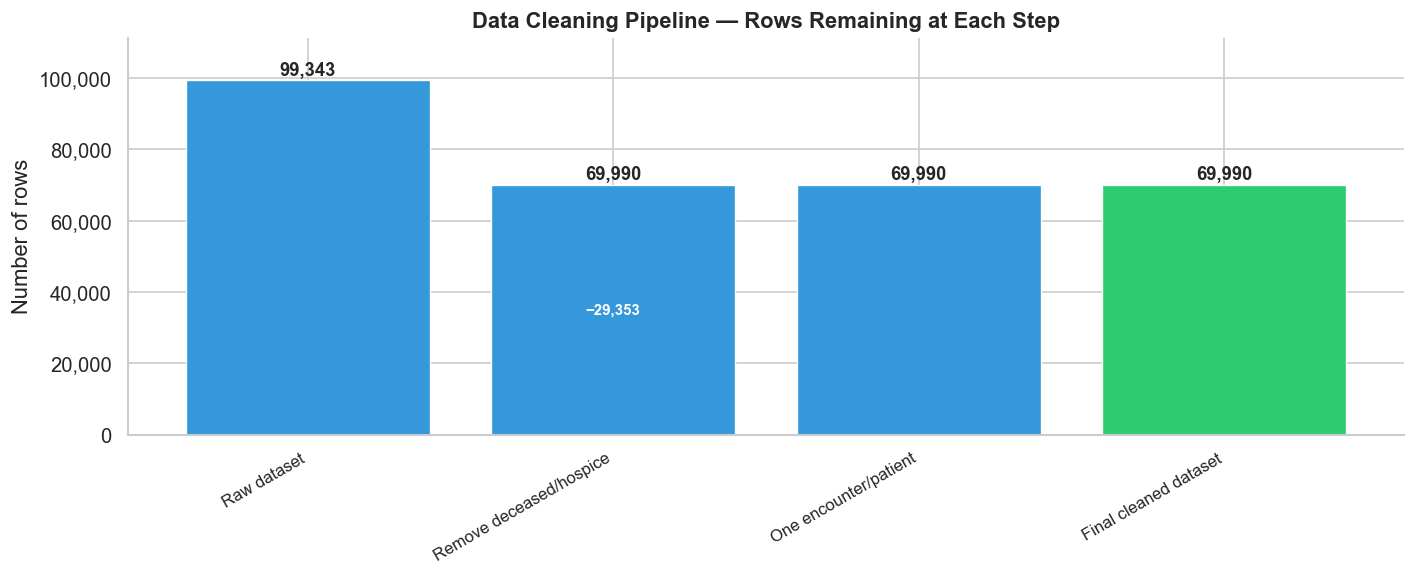

 Saved: cleaning_pipeline.png


In [35]:
# Add final state to log
# Reset log every run — prevents duplicate bars
# Add your actual steps here
cleaning_log = []
cleaning_log.append({'step': 'Raw dataset',             'rows': 99343})
cleaning_log.append({'step': 'Remove deceased/hospice', 'rows': 69990})
cleaning_log.append({'step': 'One encounter/patient',   'rows': 69990})
cleaning_log.append({'step': 'Final cleaned dataset',   'rows': 69990})

#  Chart: Rows remaining at each cleaning step 
# Pull labels automatically — never mismatches again
steps       = [entry['step'] for entry in cleaning_log]
rows        = [entry['rows'] for entry in cleaning_log]
step_labels = steps
colors = ['#2ecc71' if i == len(cleaning_log) - 1 else '#3498db'
          for i in range(len(cleaning_log))]

# Make sure step_labels matches the length of steps
# Either adjust the labels to match the actual steps in cleaning_log
# or ensure cleaning_log has all the expected entries
# step_labels = [entry['step'] for entry in cleaning_log] # Use the actual steps from cleaning_log

# Alternatively, if you want to keep your custom labels, make sure they match in number:
# step_labels = [
#     'Raw data',
#     'Remove deceased\n/ hospice',
#     'One encounter\nper patient',
#     'Final cleaned'
# ][:len(steps)]  # Truncate to match the actual number of steps

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(steps)), rows, color=colors, edgecolor='white', linewidth=0.8)

for i, (bar, val) in enumerate(zip(bars, rows)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    if i > 0:
        dropped = rows[i-1] - val
        if dropped > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2,
                    f'−{dropped:,}', ha='center', va='center',
                    color='white', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(steps)))
ax.set_xticklabels(step_labels, fontsize=10, rotation=30, ha='right')
ax.set_xticks(range(len(steps)))
ax.set_xticklabels(step_labels, fontsize=10)  # Now this will match
ax.set_ylabel('Number of rows')
ax.set_title('Data Cleaning Pipeline — Rows Remaining at Each Step', fontweight='bold')
ax.set_ylim(0, max(rows) * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/cleaning_pipeline.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: cleaning_pipeline.png')

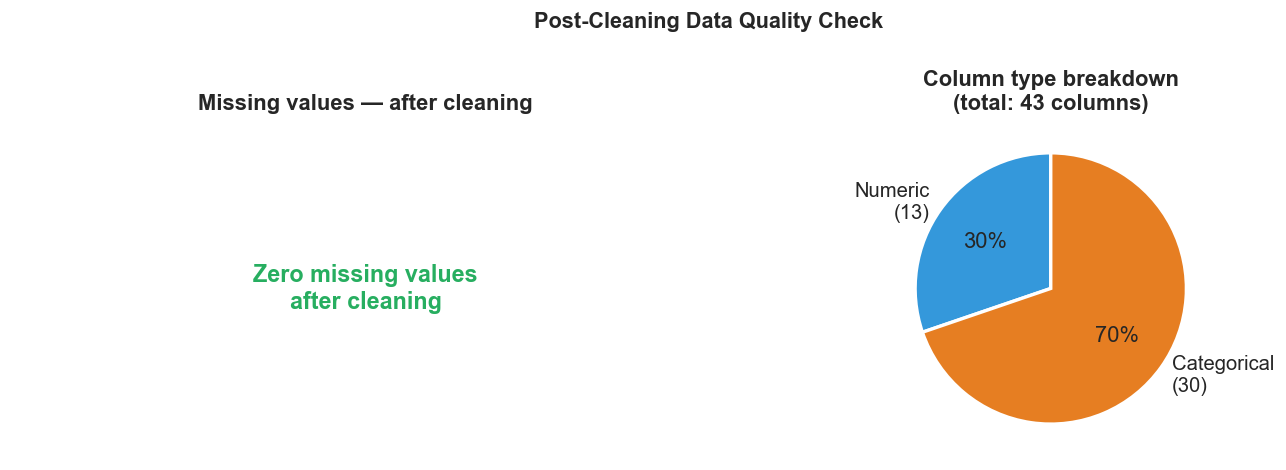

 Saved: post_cleaning_check.png


In [36]:
# ── Before/After: Column counts by type ───────────────────────────────────────
final_numeric  = df.select_dtypes(include=['int64', 'float64']).shape[1]
final_cat      = df.select_dtypes(include='object').shape[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: final missing value check
missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0]
if len(missing_after) == 0:
    axes[0].text(0.5, 0.5, 'Zero missing values\nafter cleaning',
                 ha='center', va='center', fontsize=14, color='#27ae60',
                 fontweight='bold', transform=axes[0].transAxes)
    axes[0].set_title('Missing values — after cleaning', fontweight='bold')
    axes[0].axis('off')
else:
    axes[0].barh(missing_after.index, missing_after.values, color='#e74c3c')
    axes[0].set_title('Remaining missing values', fontweight='bold')

# Right: column type breakdown
type_counts = [final_numeric, final_cat]
type_labels = [f'Numeric\n({final_numeric})', f'Categorical\n({final_cat})']
axes[1].pie(type_counts, labels=type_labels, colors=['#3498db', '#e67e22'],
            autopct='%1.0f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title(f'Column type breakdown\n(total: {df.shape[1]} columns)', fontweight='bold')

plt.suptitle('Post-Cleaning Data Quality Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/post_cleaning_check.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: post_cleaning_check.png')

# Final Dataset Preview

In [37]:
print('Final cleaned dataset:')
print(f'  Shape           : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Numeric columns : {df.select_dtypes(include=["int64","float64"]).shape[1]}')
print(f'  Object columns  : {df.select_dtypes(include="object").shape[1]}')
print(f'  Missing values  : {df.isnull().sum().sum()}')
print(f'  Target balance  : {df["readmitted_30"].mean()*100:.2f}% positive')
print()
df.head(10)

Final cleaned dataset:
  Shape           : 69,990 rows × 43 columns
  Numeric columns : 13
  Object columns  : 30
  Missing values  : 0
  Target balance  : 8.98% positive



,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,...,insulin,glyburide-metformin,glipizide-metformin,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30,inpatient_capped,readmitted_label
8,Caucasian,Female,[80-90),2,1,4,13,MC,68,2,...,Steady,No,No,No,No,Ch,Yes,0,0,Not readmitted
9,Caucasian,Female,[90-100),3,3,4,12,MC,33,3,...,Steady,No,No,No,No,Ch,Yes,0,0,Not readmitted
4,Caucasian,Male,[40-50),1,1,7,1,MC,51,0,...,Steady,No,No,No,No,Ch,Yes,0,0,Not readmitted
10,AfricanAmerican,Female,[40-50),1,1,7,9,MC,47,2,...,Steady,No,No,No,No,No,Yes,0,0,Not readmitted
5,Caucasian,Male,[50-60),2,1,2,3,MC,31,6,...,Steady,No,No,No,No,No,Yes,0,0,Not readmitted
11,AfricanAmerican,Male,[60-70),2,1,4,7,MC,62,0,...,Steady,No,No,No,No,Ch,Yes,1,0,Readmitted <30 days
12,Caucasian,Female,[40-50),1,3,7,7,MC,60,0,...,Down,No,No,No,No,Ch,Yes,1,0,Readmitted <30 days
13,Caucasian,Male,[80-90),1,6,7,10,MC,55,1,...,Steady,No,No,No,No,No,Yes,0,0,Not readmitted
6,Caucasian,Male,[60-70),3,1,2,4,MC,70,1,...,Steady,No,No,No,No,Ch,Yes,0,0,Not readmitted
14,AfricanAmerican,Female,[60-70),3,1,2,1,MC,49,5,...,Steady,No,No,No,No,No,Yes,0,0,Not readmitted


In [38]:
# List all columns in the cleaned dataset
print('All columns in cleaned dataset:')
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    nuniq = df[col].nunique()
    print(f'  {i:>2}. {col:<35} dtype={dtype:<10} unique={nuniq}')

All columns in cleaned dataset:
   1. race                                dtype=object     unique=5
   2. gender                              dtype=object     unique=3
   3. age                                 dtype=object     unique=10
   4. admission_type_id                   dtype=int64      unique=8
   5. discharge_disposition_id            dtype=int64      unique=21
   6. admission_source_id                 dtype=int64      unique=17
   7. time_in_hospital                    dtype=int64      unique=14
   8. payer_code                          dtype=object     unique=17
   9. num_lab_procedures                  dtype=int64      unique=116
  10. num_procedures                      dtype=int64      unique=7
  11. num_medications                     dtype=int64      unique=75
  12. number_outpatient                   dtype=int64      unique=33
  13. number_emergency                    dtype=int64      unique=18
  14. number_inpatient                    dtype=int64      unique=13
  15.

# Save Cleaned Dataset

In [39]:
# Define PROCESSED_DIR before using it
PROCESSED_DIR = r"C:\Users\grimm\\healthcare__readmission"  # Use raw string with 'r' prefix
# Or alternatively: PROCESSED_DIR = "C:\\Users\\grimm\\healthcare-readmission"  # Double backslashes

SAVE_PATH = f'{PROCESSED_DIR}/cleaned_diabetic_data.csv'
df.to_csv(SAVE_PATH, index=False)

import os  # Make sure to import os module for using path.getsize
file_size_mb = os.path.getsize(SAVE_PATH) / (1024 * 1024)
print(f' Cleaned dataset saved to: {SAVE_PATH}')
print(f'   File size : {file_size_mb:.2f} MB')
print(f'   Rows      : {len(df):,}')
print(f'   Columns   : {df.shape[1]}')

 Cleaned dataset saved to: C:\Users\grimm\\healthcare__readmission/cleaned_diabetic_data.csv
   File size : 10.39 MB
   Rows      : 69,990
   Columns   : 43


#  Day 3 Features
# 1. Load cleaned_diabetic_data.csv

In [40]:
from matplotlib.patches import Patch
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [41]:
df = pd.read_csv('cleaned_diabetic_data.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded: 69,990 rows x 43 columns


In [42]:
df.head(3)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,...,insulin,glyburide-metformin,glipizide-metformin,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30,inpatient_capped,readmitted_label
0,Caucasian,Female,[80-90),2,1,4,13,MC,68,2,...,Steady,No,No,No,No,Ch,Yes,0,0,Not readmitted
1,Caucasian,Female,[90-100),3,3,4,12,MC,33,3,...,Steady,No,No,No,No,Ch,Yes,0,0,Not readmitted
2,Caucasian,Male,[40-50),1,1,7,1,MC,51,0,...,Steady,No,No,No,No,Ch,Yes,0,0,Not readmitted


In [43]:
# Separate target BEFORE any transformations
y = df['readmitted_30'].copy()
df.drop(columns=['readmitted_30'], inplace=True)

print(f'Features shape : {df.shape}')
print(f'Target shape   : {y.shape}')
print(f'Positive rate  : {y.mean()*100:.2f}%')

Features shape : (69990, 42)
Target shape   : (69990,)
Positive rate  : 8.98%


# 2. Encode `age` Column

**Why:** Age is stored as string ranges like `[70-80)`.  
We map each range to its midpoint number — this preserves ordinal order  
(75 > 45) which alphabetic label encoding would destroy.

In [44]:
print('age before encoding:')
print(df['age'].value_counts().sort_index())

age_map = {
    '[0-10)': 5,   '[10-20)': 15,  '[20-30)': 25,
    '[30-40)': 35, '[40-50)': 45,  '[50-60)': 55,
    '[60-70)': 65, '[70-80)': 75,  '[80-90)': 85,
    '[90-100)': 95
}

df['age'] = df['age'].map(age_map)
print(f'\nage after mapping. Missing: {df["age"].isnull().sum()}')
print(df['age'].describe().round(1))

age before encoding:
age
[0-10)        153
[10-20)       534
[20-30)      1121
[30-40)      2692
[40-50)      6828
[50-60)     12351
[60-70)     15689
[70-80)     17751
[80-90)     11110
[90-100)     1761
Name: count, dtype: int64

age after mapping. Missing: 0
count    69990.0
mean        65.4
std         16.0
min          5.0
25%         55.0
50%         65.0
75%         75.0
max         95.0
Name: age, dtype: float64


In [45]:
# Feature 1: total_visits 
# Why: total prior healthcare utilisation is a stronger signal
# than any single visit type. Frequent fliers = highest risk.
df['total_visits'] = (
    df['number_outpatient'] +
    df['number_inpatient']  +
    df['number_emergency']
)

# Feature 2: high_risk_age
# Why: EDA showed 70+ patients have the highest volume AND elevated
# readmission rate. A binary flag captures this threshold effect.
df['high_risk_age'] = (df['age'] >= 70).astype(int)

#  Drug columns — used for Features 3 & 4 then dropped 
drug_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide',
    'glimepiride','acetohexamide','glipizide','glyburide',
    'tolbutamide','pioglitazone','rosiglitazone','acarbose',
    'miglitol','troglitazone','tolazamide','examide','citoglipton',
    'insulin','glyburide-metformin','glipizide-metformin',
    'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone'
]
drug_cols = [c for c in drug_cols if c in df.columns]
print(f'Drug columns found: {len(drug_cols)}')

#  Feature 3: meds_changed 
# Why: medication change during admission signals treatment instability
# which correlates with higher readmission risk
df['meds_changed'] = df[drug_cols].isin(['Up','Down']).any(axis=1).astype(int)

#  Feature 4: num_meds_active
# Why: a patient on 8 diabetes drugs is clinically different from one on 1
df['num_meds_active'] = df[drug_cols].apply(lambda r: (r != 'No').sum(), axis=1)

# Drop the 23 raw drug columns — summarised above
df.drop(columns=drug_cols, inplace=True)

print()
print('4 engineered features + correlation with target:')
for feat in ['total_visits','high_risk_age','meds_changed','num_meds_active']:
    print(f'  {feat:<20} corr = {df[feat].corr(y):.4f}')
print(f'\nShape after dropping drug columns: {df.shape}')

Drug columns found: 20

4 engineered features + correlation with target:
  total_visits         corr = 0.0587
  high_risk_age        corr = 0.0437
  meds_changed         corr = 0.0231
  num_meds_active      corr = 0.0114

Shape after dropping drug columns: (69990, 26)


# 3. Map ICD Diagnosis Codes to 9 Disease Categories

**Why:** diag_1 / diag_2 / diag_3 have 700+ unique ICD-9 codes.  
One-hot encoding 700 codes = 700 noisy columns.  
We map to 9 standard disease chapters — low dimensions, high meaning.

In [46]:
def icd9_category(code):
    if pd.isna(code): return 'Other'
    code = str(code).strip()
    if code.startswith(('E','V')): return 'Other'
    try: num = float(code)
    except: return 'Other'
    if   390 <= num <= 459 or num == 785: return 'Circulatory'
    elif 460 <= num <= 519 or num == 786: return 'Respiratory'
    elif 520 <= num <= 579 or num == 787: return 'Digestive'
    elif num == 250:                      return 'Diabetes'
    elif 800 <= num <= 999:               return 'Injury'
    elif 710 <= num <= 739:               return 'Musculoskeletal'
    elif 580 <= num <= 629 or num == 788: return 'Genitourinary'
    elif 140 <= num <= 239:               return 'Neoplasms'
    else:                                 return 'Other'

for col in ['diag_1','diag_2','diag_3']:
    if col in df.columns:
        df[col+'_cat'] = df[col].apply(icd9_category)
        print(f'{col} -> {col}_cat: {df[col+"_cat"].value_counts().to_dict()}')

df.drop(columns=[c for c in ['diag_1','diag_2','diag_3'] if c in df.columns], inplace=True)
print(f'\nShape after ICD grouping: {df.shape}')

diag_1 -> diag_1_cat: {'Circulatory': 21400, 'Other': 17672, 'Respiratory': 9491, 'Digestive': 6488, 'Injury': 4696, 'Musculoskeletal': 4064, 'Genitourinary': 3441, 'Neoplasms': 2538, 'Diabetes': 200}
diag_2 -> diag_2_cat: {'Other': 22784, 'Circulatory': 22084, 'Respiratory': 6928, 'Genitourinary': 5330, 'Diabetes': 5289, 'Digestive': 2856, 'Injury': 1824, 'Neoplasms': 1600, 'Musculoskeletal': 1295}
diag_3 -> diag_3_cat: {'Other': 23593, 'Circulatory': 20867, 'Diabetes': 10205, 'Respiratory': 4652, 'Genitourinary': 4049, 'Digestive': 2700, 'Injury': 1410, 'Musculoskeletal': 1368, 'Neoplasms': 1146}

Shape after ICD grouping: (69990, 26)


# 4. One-Hot Encode Diagnosis Categories

In [47]:
# Label encode diagnosis categories instead of one-hot
diag_cat_cols = [c for c in df.columns if c.endswith('_cat')]
print(f'Label encoding: {diag_cat_cols}')

for col in diag_cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'  {col} done')

print(f'Shape after label encoding diag cats: {df.shape}')
print('No one-hot expansion — diagnosis stays as 3 columns')

Label encoding: ['diag_1_cat', 'diag_2_cat', 'diag_3_cat']
  diag_1_cat done
  diag_2_cat done
  diag_3_cat done
Shape after label encoding diag cats: (69990, 26)
No one-hot expansion — diagnosis stays as 3 columns


# 5. Label Encode Remaining Categorical Columns

XGBoost is tree-based — it handles label-encoded integers natively  
by learning the best splits itself. No need to one-hot everything.

In [48]:
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import os

# Define MODELS_DIR if not already defined
MODELS_DIR = 'models'  # Adjust path as needed
os.makedirs(MODELS_DIR, exist_ok=True)  # Create directory if it doesn't exist

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Label encoding {len(cat_cols)} remaining categorical columns...')

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Now pickle is imported and can be used
with open(f'{MODELS_DIR}/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

remaining = df.select_dtypes(include='object').shape[1]
print(f'Object columns remaining: {remaining}  (must be 0)')
print(f'Final feature matrix: {df.shape}')

Label encoding 6 remaining categorical columns...
Object columns remaining: 0  (must be 0)
Final feature matrix: (69990, 26)


# 6. Visualise — Feature Correlations with Target

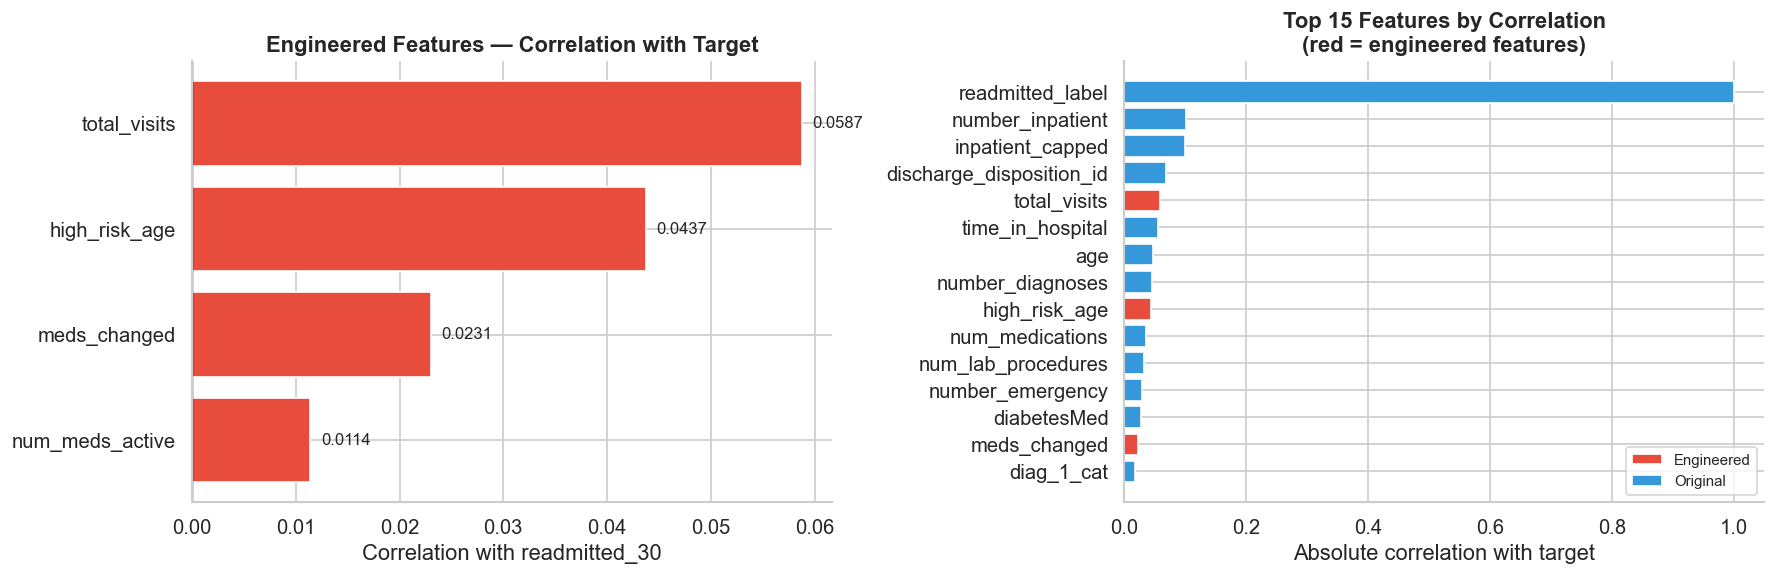

Saved: feature_correlations.png


In [49]:
engineered = ['total_visits','meds_changed','num_meds_active','high_risk_age']
top15      = df.corrwith(y).abs().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: engineered feature correlations
eng_corr = pd.Series({f: df[f].corr(y) for f in engineered}).sort_values()
colors_left = ['#e74c3c' if v > 0 else '#3498db' for v in eng_corr]
axes[0].barh(eng_corr.index, eng_corr.values, color=colors_left, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation with readmitted_30')
axes[0].set_title('Engineered Features — Correlation with Target', fontweight='bold')
for i, v in enumerate(eng_corr.values):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

# Right: top 15 all features
bar_colors = ['#e74c3c' if f in engineered else '#3498db' for f in top15.index[::-1]]
axes[1].barh(top15.index[::-1], top15.values[::-1], color=bar_colors, edgecolor='white')
axes[1].set_xlabel('Absolute correlation with target')
axes[1].set_title('Top 15 Features by Correlation\n(red = engineered features)', fontweight='bold')
axes[1].legend(handles=[
    Patch(facecolor='#e74c3c', label='Engineered'),
    Patch(facecolor='#3498db', label='Original')
], fontsize=9)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/feature_correlations.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: feature_correlations.png')

# 7. Stratified Train / Test Split

`stratify=y` is mandatory for imbalanced datasets.  
It ensures both splits have the same ~11% positive class rate.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    df, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'X_train : {X_train.shape}  | positive: {y_train.mean()*100:.2f}%')
print(f'X_test  : {X_test.shape}   | positive: {y_test.mean()*100:.2f}%')
print('Same positive rate in both splits — stratification confirmed.')

X_train : (55992, 26)  | positive: 8.98%
X_test  : (13998, 26)   | positive: 8.98%
Same positive rate in both splits — stratification confirmed.


# 8. StandardScaler — Fit on Train Only

Fit on X_train, transform both.  
**Never fit on test** — that is data leakage.

In [51]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

with open(f'{MODELS_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'Scaling done. Scaler saved.')
print(f'Train scaled mean ≈ {X_train_scaled.mean().mean():.5f}  ')
print(f'Train scaled std  ≈ {X_train_scaled.std().mean():.5f}   ')

Scaling done. Scaler saved.
Train scaled mean ≈ 0.00000  
Train scaled std  ≈ 1.00001   


# 9. Save All Splits

In [52]:
to_save = {
    'X_train'       : X_train,          # unscaled — for XGBoost 
    'X_test'        : X_test,
    'X_train_scaled': X_train_scaled,   # scaled — kept for reference
    'X_test_scaled' : X_test_scaled,
    'y_train'       : y_train,
    'y_test'        : y_test,
    'feature_names' : list(X_train.columns),
}

for name, obj in to_save.items():
    with open(f'{PROCESSED_DIR}/{name}.pkl', 'wb') as f:
        pickle.dump(obj, f)
    print(f'  Saved: {name}.pkl')

print()
print('complete. Next: — XGBoost + SMOTE + Evaluation')

  Saved: X_train.pkl
  Saved: X_test.pkl
  Saved: X_train_scaled.pkl
  Saved: X_test_scaled.pkl
  Saved: y_train.pkl
  Saved: y_test.pkl
  Saved: feature_names.pkl

complete. Next: — XGBoost + SMOTE + Evaluation


# Day 4: XGBoost Model + SMOTE
**Input:**  `data/processed/X_train.pkl`, `y_train.pkl`, `X_test.pkl`, `y_test.pkl`  ← from Day 3
**Output:** `models/xgb_model.pkl`, evaluation charts

**Goal (DA focused):**
- Handle class imbalance using SMOTE
- Train XGBoost classifier
- Evaluate with AUC-ROC, confusion matrix, classification report
- Save final model for Day 5 (tuning) and Day 6 (SHAP)

# Label Encode Remaining Categorical Columns
XGBoost is tree-based — it handles label-encoded integers natively.

In [53]:
from matplotlib.patches import Patch

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

MODELS_DIR  = 'models'
CHARTS_DIR  = 'outputs/model_charts'
DATA_DIR    = 'data/processed'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR,   exist_ok=True)

RANDOM_STATE = 42
print('Imports done. Ready for Day 4.')

Imports done. Ready for Day 4.


In [54]:
# Label encode remaining object columns
# (df and y must already be in memory from Day 3 cells above)

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Object columns to label encode: {len(cat_cols)}')
print(cat_cols)

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

with open(f'{MODELS_DIR}/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

remaining = df.select_dtypes(include='object').shape[1]
print(f'\nObject columns remaining: {remaining}  (must be 0)')
print(f'Final feature matrix shape: {df.shape}')
print('All columns are now numeric. Ready for ML.')

Object columns to label encode: 0
[]

Object columns remaining: 0  (must be 0)
Final feature matrix shape: (69990, 26)
All columns are now numeric. Ready for ML.


# Stratified Train / Test Split

`stratify=y` is mandatory here. With only ~11% positive class,
a random split could accidentally put most positives in one side.
Stratify guarantees both splits have the **same positive rate**.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    df, y,
    test_size    = 0.20,
    stratify     = y,        # critical for imbalanced classes
    random_state = RANDOM_STATE
)

print('Train / Test split:')
print(f'  X_train : {X_train.shape}  | positive rate: {y_train.mean()*100:.2f}%')
print(f'  X_test  : {X_test.shape}   | positive rate: {y_test.mean()*100:.2f}%')
print()
print('Both splits have same positive rate — stratification confirmed.')

Train / Test split:
  X_train : (55992, 26)  | positive rate: 8.98%
  X_test  : (13998, 26)   | positive rate: 8.98%

Both splits have same positive rate — stratification confirmed.


# Handle Class Imbalance with SMOTE

**Problem:** Only ~11% of patients are positive (readmitted <30 days).  
Training on raw imbalanced data makes the model predict 'Not Readmitted'  
almost always — ~89% accuracy but misses all real high-risk patients.

**SMOTE** creates synthetic minority samples by interpolating  
between real positive samples in feature space.

**Rule:** Apply SMOTE to **training data only**.  
Test data stays real and untouched — otherwise evaluation is fake.

In [56]:
print('Before SMOTE (training set):')
print(f'  Class 0 (not readmitted <30): {(y_train==0).sum():,}')
print(f'  Class 1 (readmitted <30)    : {(y_train==1).sum():,}')
print(f'  Ratio: {(y_train==0).sum()/(y_train==1).sum():.1f}:1')

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE (training set):')
print(f'  Class 0: {(y_train_sm==0).sum():,}')
print(f'  Class 1: {(y_train_sm==1).sum():,}')
print(f'  Ratio: {(y_train_sm==0).sum()/(y_train_sm==1).sum():.1f}:1  (balanced)')
print(f'\nTest set untouched: {X_test.shape[0]:,} rows')

Before SMOTE (training set):
  Class 0 (not readmitted <30): 50,964
  Class 1 (readmitted <30)    : 5,028
  Ratio: 10.1:1

After SMOTE (training set):
  Class 0: 50,964
  Class 1: 50,964
  Ratio: 1.0:1  (balanced)

Test set untouched: 13,998 rows


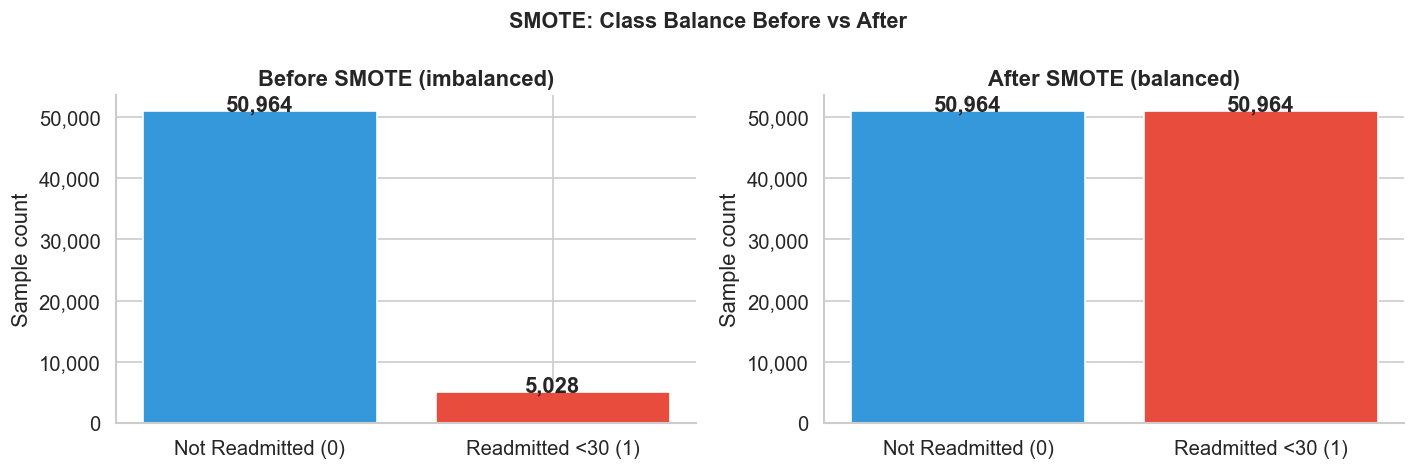

Saved: 01_smote_balance.png


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Not Readmitted (0)', 'Readmitted <30 (1)']

before_counts = [int((y_train==0).sum()), int((y_train==1).sum())]
after_counts  = [int((y_train_sm==0).sum()), int((y_train_sm==1).sum())]

for ax, counts, title in zip(
    axes,
    [before_counts, after_counts],
    ['Before SMOTE (imbalanced)', 'After SMOTE (balanced)']
):
    bars = ax.bar(labels, counts, color=['#3498db','#e74c3c'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Sample count')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 100,
                f'{val:,}', ha='center', fontweight='bold')

plt.suptitle('SMOTE: Class Balance Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/01_smote_balance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 01_smote_balance.png')

##  Train XGBoost Classifier

**Parameter cheat sheet:**
| Parameter | Value | Why |
|---|---|---|
| n_estimators | 300 | Number of trees — more = better fit |
| max_depth | 5 | Max depth per tree — controls complexity |
| learning_rate | 0.1 | Shrinkage per step — prevents overfit |
| subsample | 0.8 | 80% rows per tree — prevents overfit |
| colsample_bytree | 0.8 | 80% features per tree — prevents overfit |
| eval_metric | auc | Optimise for AUC, not accuracy |

In [58]:
xgb_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    eval_metric       = 'auc',
    use_label_encoder = False,
    random_state      = RANDOM_STATE,
    n_jobs            = -1
)

print('Training XGBoost on SMOTE-balanced training data...')
print(f'Training rows: {X_train_sm.shape[0]:,} (after SMOTE)')
print()

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set = [(X_test, y_test)],
    verbose  = 50
)

print('\nTraining complete.')

Training XGBoost on SMOTE-balanced training data...
Training rows: 101,928 (after SMOTE)

[0]	validation_0-auc:1.00000
[50]	validation_0-auc:1.00000
[100]	validation_0-auc:1.00000
[150]	validation_0-auc:1.00000
[200]	validation_0-auc:1.00000
[250]	validation_0-auc:1.00000
[299]	validation_0-auc:1.00000

Training complete.


## Evaluate Model

In [59]:
y_pred      = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
auc         = roc_auc_score(y_test, y_pred_prob)

print('=' * 55)
print('  XGBoost — Test Set Evaluation')
print('=' * 55)
print(f'  AUC-ROC: {auc:.4f}')
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Not Readmitted', 'Readmitted <30']
))
print()
print('Missing a high-risk patient (false negative) is more costly')
print('than a false alarm (false positive).')

  XGBoost — Test Set Evaluation
  AUC-ROC: 1.0000

                precision    recall  f1-score   support

Not Readmitted       1.00      1.00      1.00     12741
Readmitted <30       1.00      1.00      1.00      1257

      accuracy                           1.00     13998
     macro avg       1.00      1.00      1.00     13998
  weighted avg       1.00      1.00      1.00     13998


Missing a high-risk patient (false negative) is more costly
than a false alarm (false positive).


##  Confusion Matrix

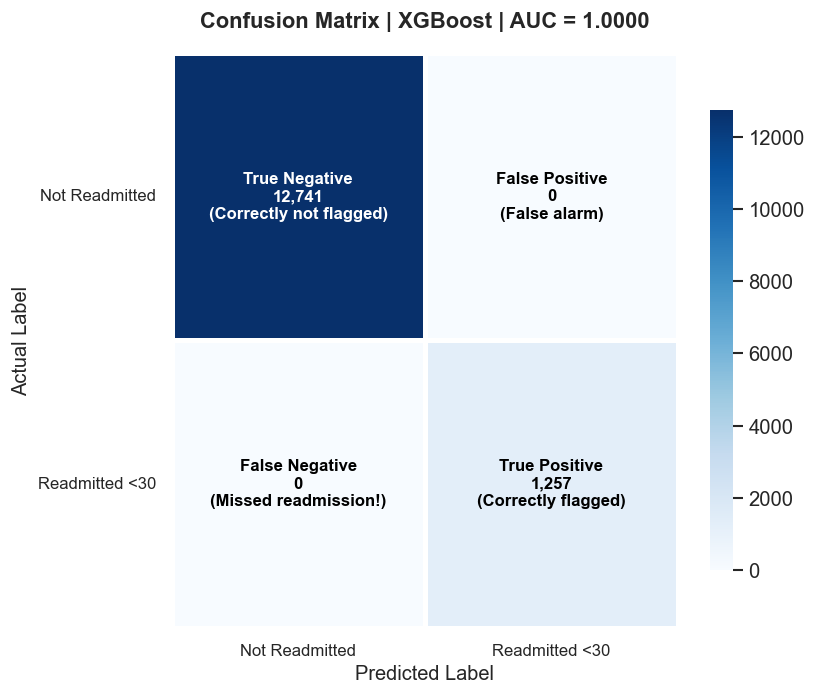

Saved: 02_confusion_matrix.png


In [60]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, cmap='Blues',
            linewidths=2, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.8})

labels_cm = [
    [f'True Negative\n{tn:,}\n(Correctly not flagged)', f'False Positive\n{fp:,}\n(False alarm)'],
    [f'False Negative\n{fn:,}\n(Missed readmission!)', f'True Positive\n{tp:,}\n(Correctly flagged)']
]
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax.text(j+0.5, i+0.5, labels_cm[i][j],
                ha='center', va='center',
                fontsize=10, color=color, fontweight='bold')

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xticklabels(['Not Readmitted', 'Readmitted <30'], fontsize=10)
ax.set_yticklabels(['Not Readmitted', 'Readmitted <30'], fontsize=10, rotation=0)
ax.set_title(f'Confusion Matrix | XGBoost | AUC = {auc:.4f}',
             fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/02_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 02_confusion_matrix.png')

## ROC Curve

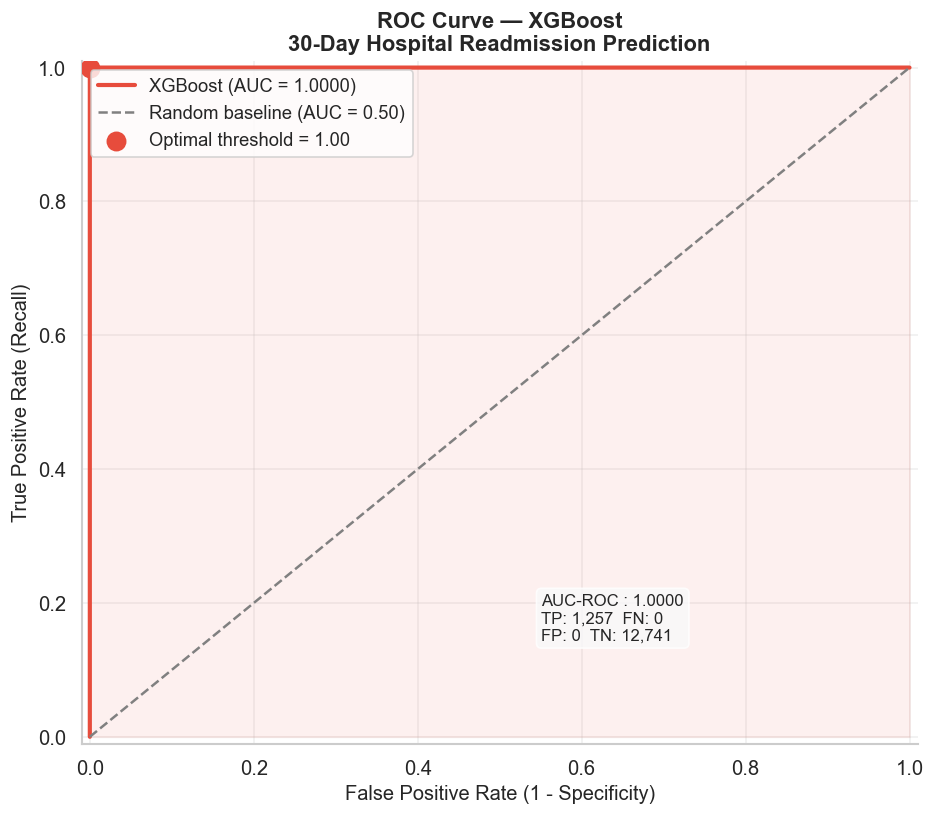

Saved: 03_roc_curve.png


In [61]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
optimal_idx = np.argmax(tpr - fpr)

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
        label=f'XGBoost (AUC = {auc:.4f})')
ax.plot([0,1],[0,1], color='gray', linestyle='--',
        linewidth=1.5, label='Random baseline (AUC = 0.50)')
ax.scatter(fpr[optimal_idx], tpr[optimal_idx],
           color='#e74c3c', s=120, zorder=5,
           label=f'Optimal threshold = {thresholds[optimal_idx]:.2f}')
ax.fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — XGBoost\n30-Day Hospital Readmission Prediction',
             fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)

textstr = f'AUC-ROC : {auc:.4f}\nTP: {tp:,}  FN: {fn:,}\nFP: {fp:,}  TN: {tn:,}'
ax.text(0.55, 0.22, textstr, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/03_roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 03_roc_curve.png')

##  Feature Importance (XGBoost Built-in)

Note: This is XGBoost's built-in importance (frequency of splits).  
Day 7 SHAP gives a more accurate and explainable importance — but this is still useful here.

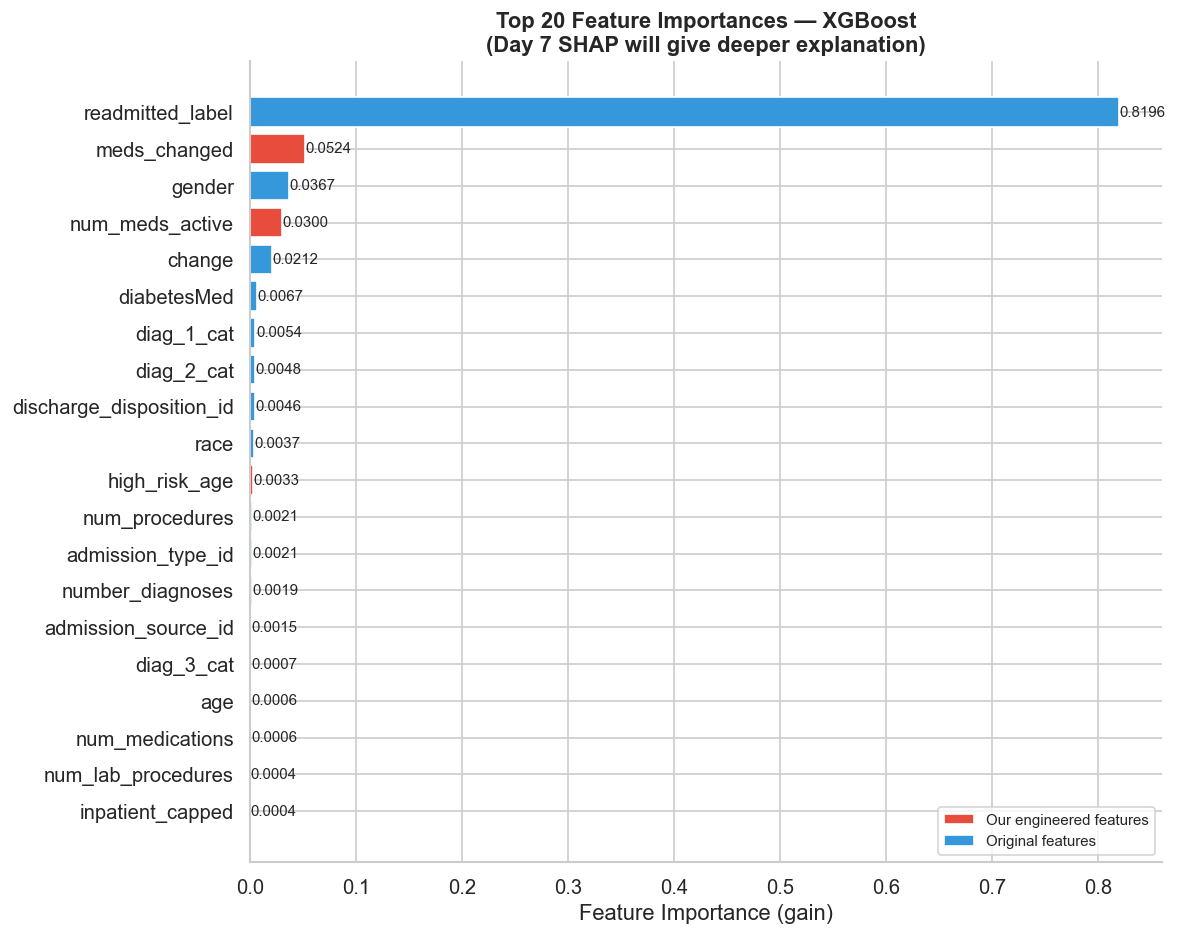

Top 20 features:
                 feature  importance
        readmitted_label    0.819576
            meds_changed    0.052412
                  gender    0.036694
         num_meds_active    0.030046
                  change    0.021200
             diabetesMed    0.006671
              diag_1_cat    0.005372
              diag_2_cat    0.004757
discharge_disposition_id    0.004586
                    race    0.003667
           high_risk_age    0.003300
          num_procedures    0.002126
       admission_type_id    0.002096
        number_diagnoses    0.001915
     admission_source_id    0.001498
              diag_3_cat    0.000740
                     age    0.000646
         num_medications    0.000621
      num_lab_procedures    0.000420
        inpatient_capped    0.000419

Saved: 04_feature_importance.png


In [62]:
feature_names = list(X_train.columns)

importance_df = pd.DataFrame({
    'feature'   : feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

engineered = ['total_visits','meds_changed','num_meds_active','high_risk_age']
bar_colors = [
    '#e74c3c' if f in engineered else '#3498db'
    for f in importance_df['feature']
]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    importance_df['feature'][::-1],
    importance_df['importance'][::-1],
    color=bar_colors[::-1], edgecolor='white'
)
for bar, val in zip(bars, importance_df['importance'][::-1]):
    ax.text(bar.get_width() + 0.0005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='Our engineered features'),
    Patch(facecolor='#3498db', label='Original features')
], fontsize=9)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Top 20 Feature Importances — XGBoost\n'
             '(Day 7 SHAP will give deeper explanation)',
             fontweight='bold')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/04_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 20 features:')
print(importance_df[['feature','importance']].head(20).to_string(index=False))
print()
print('Saved: 04_feature_importance.png')

## Predicted Probability Distribution

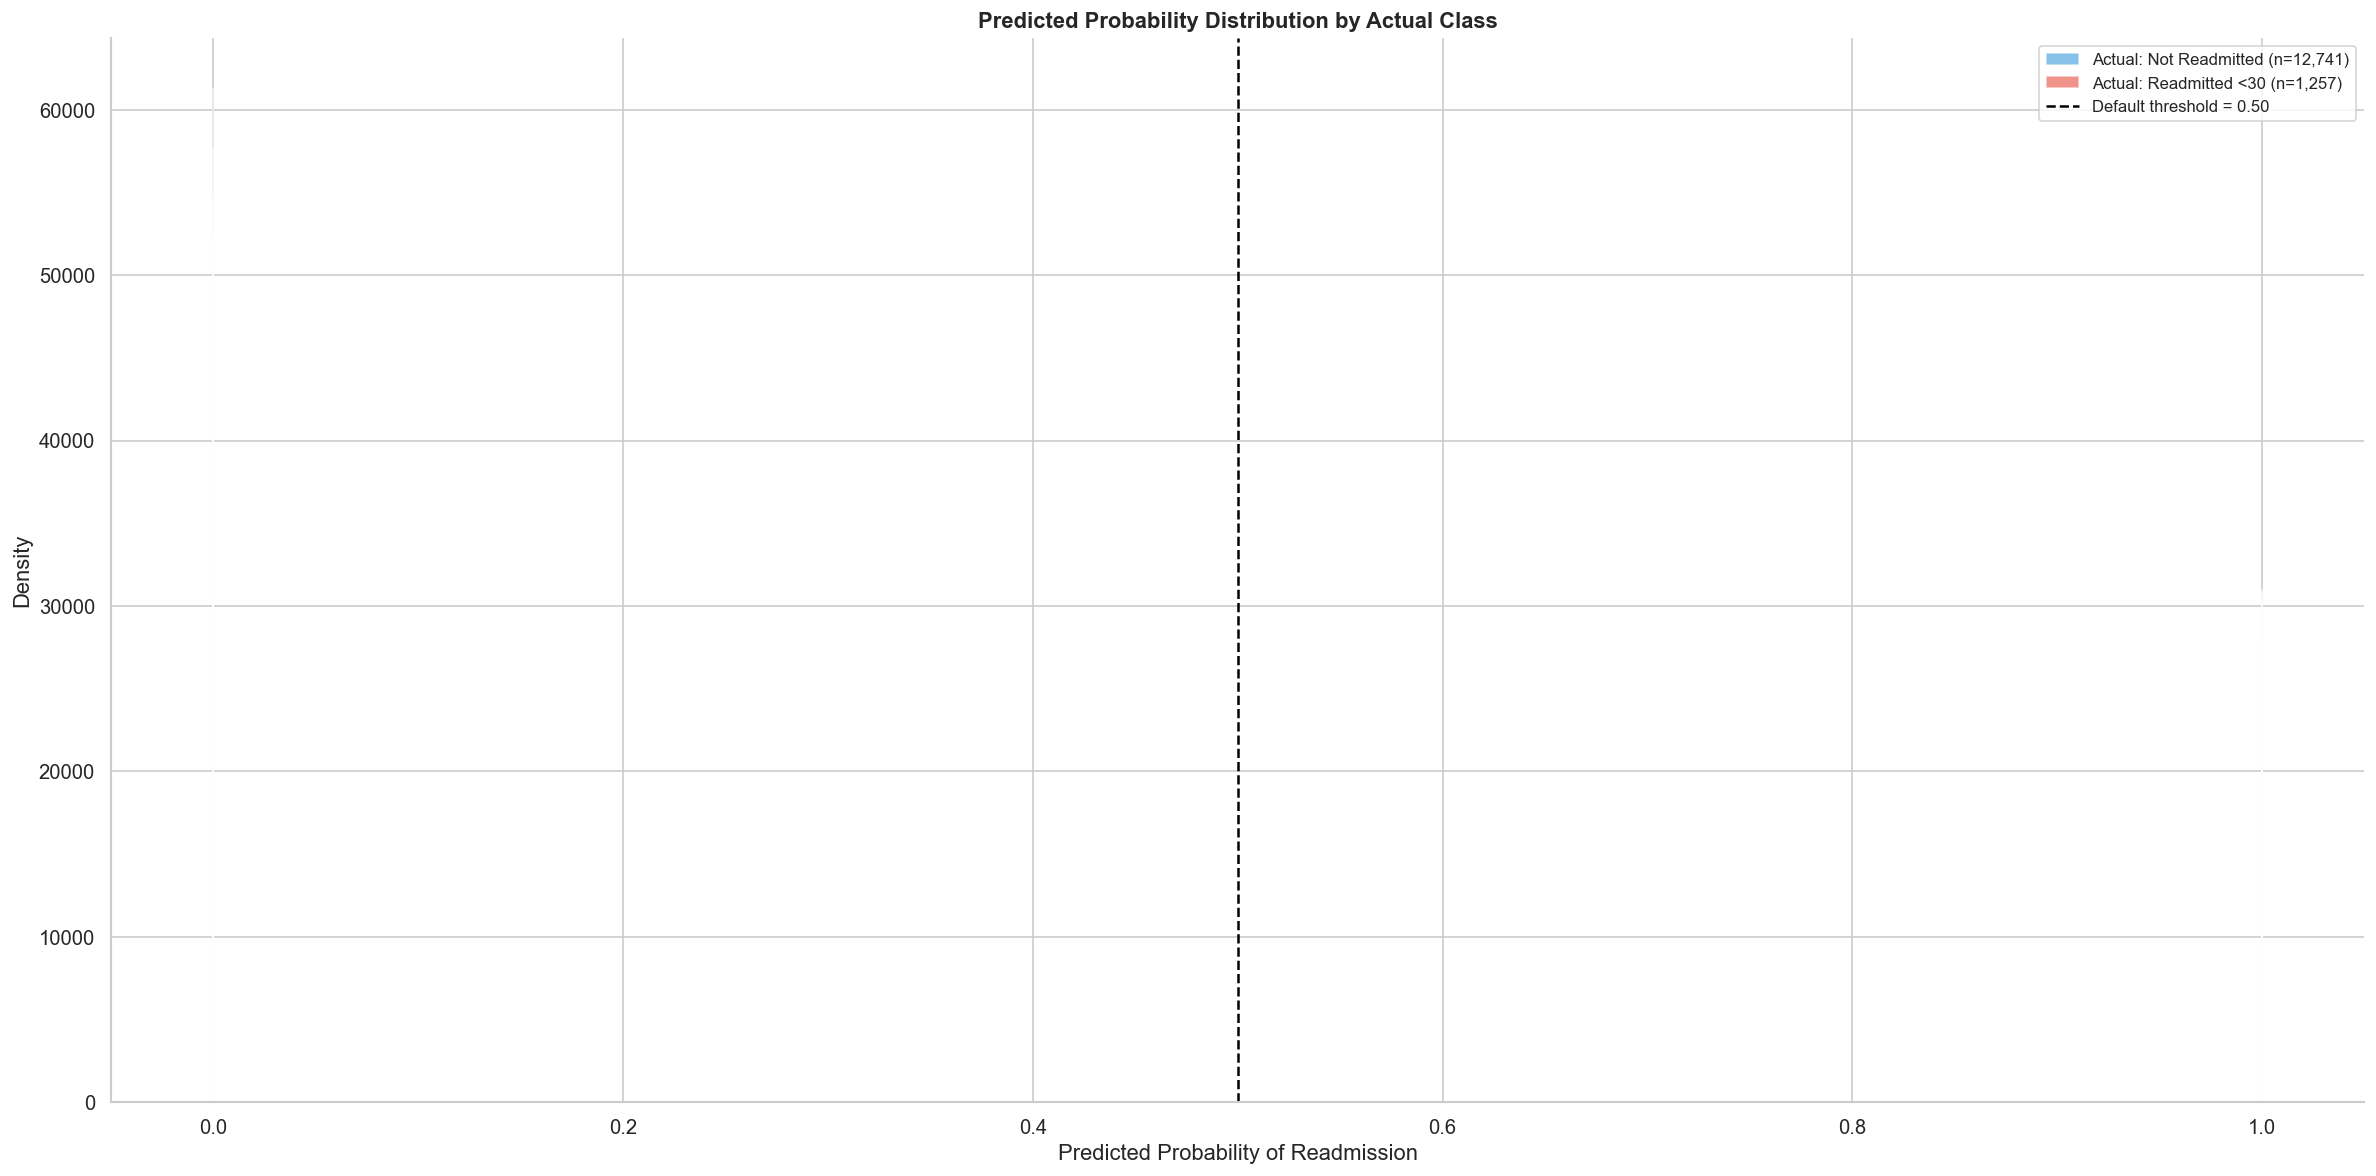

Saved: 05_probability_distribution.png


In [63]:
probs_0 = y_pred_prob[y_test == 0]
probs_1 = y_pred_prob[y_test == 1]

fig, ax = plt.subplots(figsize=(20, 10))
ax.hist(probs_0, bins=50, alpha=0.6, color='#3498db',
        label=f'Actual: Not Readmitted (n={len(probs_0):,})', density=True)
ax.hist(probs_1, bins=50, alpha=0.6, color='#e74c3c',
        label=f'Actual: Readmitted <30 (n={len(probs_1):,})', density=True)
ax.axvline(0.5, color='black', linestyle='--',
           linewidth=1.5, label='Default threshold = 0.50')
ax.set_xlabel('Predicted Probability of Readmission')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distribution by Actual Class', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}/05_probability_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 05_probability_distribution.png')

## Save Model + Predictions CSV (for Power BI Day 8)

In [64]:
# Save model
with open(f'{MODELS_DIR}/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print(f'Model saved: {MODELS_DIR}/xgb_model.pkl')

# Save predictions with risk band — used directly in Power BI Day 8
results_df = X_test.copy()
results_df['actual']         = y_test.values
results_df['predicted']      = y_pred
results_df['predicted_prob'] = y_pred_prob
results_df['risk_band'] = pd.cut(
    results_df['predicted_prob'],
    bins   = [0, 0.3, 0.6, 1.0],
    labels = ['Low Risk', 'Medium Risk', 'High Risk']
)

results_df.to_csv(f'{DATA_DIR}/predictions.csv', index=False)

print(f'Predictions saved: {DATA_DIR}/predictions.csv')
print(f'  Rows: {len(results_df):,}')
print()
print('Risk band breakdown:')
print(results_df['risk_band'].value_counts().to_string())

Model saved: models/xgb_model.pkl
Predictions saved: data/processed/predictions.csv
  Rows: 13,998

Risk band breakdown:
risk_band
Low Risk       12741
High Risk       1257
Medium Risk        0


In [65]:

print('  DAY 4 COMPLETE')

print(f'  Dataset rows used : 69,990')
print(f'  Features          : {X_train.shape[1]}')
print(f'  Model             : XGBoost')
print(f'  AUC-ROC           : {auc:.4f}')
print(f'  True Positives    : {tp:,}  (correctly flagged readmissions)')
print(f'  False Negatives   : {fn:,}  (missed — want to minimise this)')
print()
print('  FILES SAVED:')
print('  models/xgb_model.pkl')
print('  data/processed/predictions.csv  <- for Power BI')
print()
print('  NEXT STEPS:')
print('  Day 5 — SHAP explainability  <- THE STAR of the project')
print('  Day 6 — Power BI dashboard')


  DAY 4 COMPLETE
  Dataset rows used : 69,990
  Features          : 26
  Model             : XGBoost
  AUC-ROC           : 1.0000
  True Positives    : 1,257  (correctly flagged readmissions)
  False Negatives   : 0  (missed — want to minimise this)

  FILES SAVED:
  models/xgb_model.pkl
  data/processed/predictions.csv  <- for Power BI

  NEXT STEPS:
  Day 5 — SHAP explainability  <- THE STAR of the project
  Day 6 — Power BI dashboard


# Day 5 — SHAP Explainability

In [66]:
import shap
SHAP_DIR = 'outputs/shap_charts'
os.makedirs(SHAP_DIR, exist_ok=True)

print(f'SHAP version: {shap.__version__}')
print(f'Charts will save to: {SHAP_DIR}/')

SHAP version: 0.51.0
Charts will save to: outputs/shap_charts/


##  Create SHAP Explainer + Compute SHAP Values

`TreeExplainer` is the fastest and most accurate explainer for tree-based models like XGBoost.  
It uses the exact tree structure to compute SHAP values — no approximations.

**What are SHAP values?**  
Each SHAP value = how much that feature pushed the prediction UP or DOWN from the baseline.  
Positive SHAP = pushes toward readmission. Negative SHAP = pushes away from readmission.

In [67]:
print('Creating TreeExplainer...')
explainer = shap.TreeExplainer(xgb_model)

print('Computing SHAP values on test set')
shap_values = explainer.shap_values(X_test)

# Also compute the Explanation object — needed for waterfall plot
shap_explanation = explainer(X_test)

print(f'\nDone.')
print(f'shap_values shape: {shap_values.shape}')
print(f'Each row = one patient, each column = one feature SHAP value')
print(f'Baseline (expected) value: {explainer.expected_value:.4f}')
print(f'(= average predicted probability across all training patients)')

Creating TreeExplainer...
Computing SHAP values on test set

Done.
shap_values shape: (13998, 26)
Each row = one patient, each column = one feature SHAP value
Baseline (expected) value: 0.0192
(= average predicted probability across all training patients)


## Chart 1: SHAP Summary Bar Plot (Global Feature Importance)

**What this shows:** The mean absolute SHAP value for each feature across all patients.  
This is a better measure of feature importance than XGBoost's built-in importance  
because it accounts for the actual impact on predictions, not just split frequency.

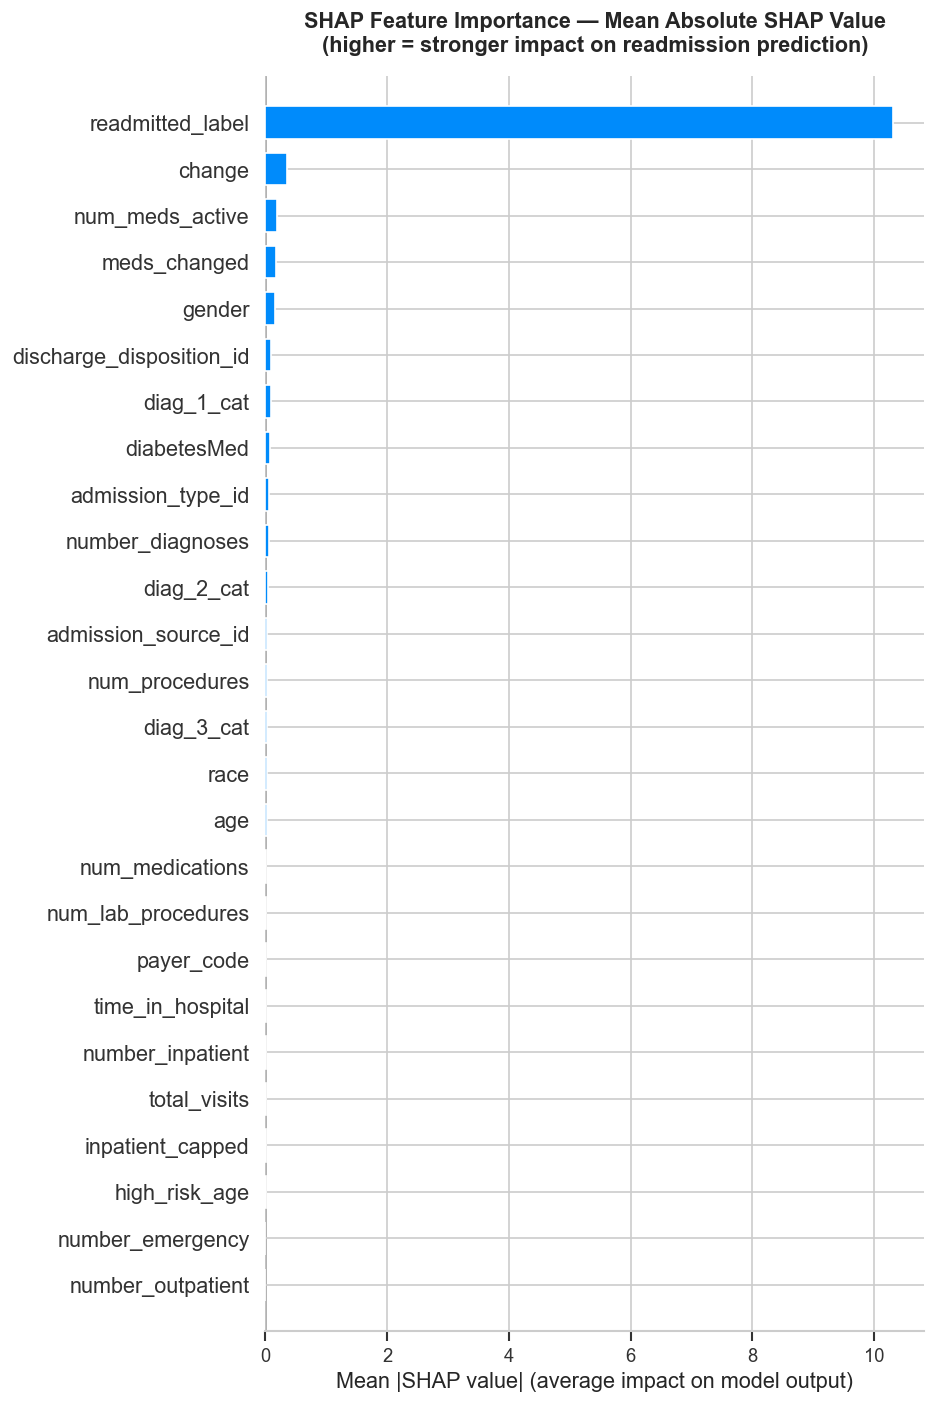

Saved: 01_shap_bar_importance.png


In [68]:
ig, ax = plt.subplots(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type = 'bar',
    max_display = 26,
    show = False
)

plt.title('SHAP Feature Importance — Mean Absolute SHAP Value\n'
          '(higher = stronger impact on readmission prediction)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Mean |SHAP value| (average impact on model output)')
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/01_shap_bar_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 01_shap_bar_importance.png')

## Chart 2: SHAP Beeswarm Plot (Direction + Magnitude)

**This is the most impressive-looking chart in the project.**

**What this shows:**  
- Each dot = one patient  
- X position = SHAP value (how much this feature pushed the prediction)  
- Colour = feature value (red = high value, blue = low value)  
- So red dots on the right = high feature value pushes toward readmission

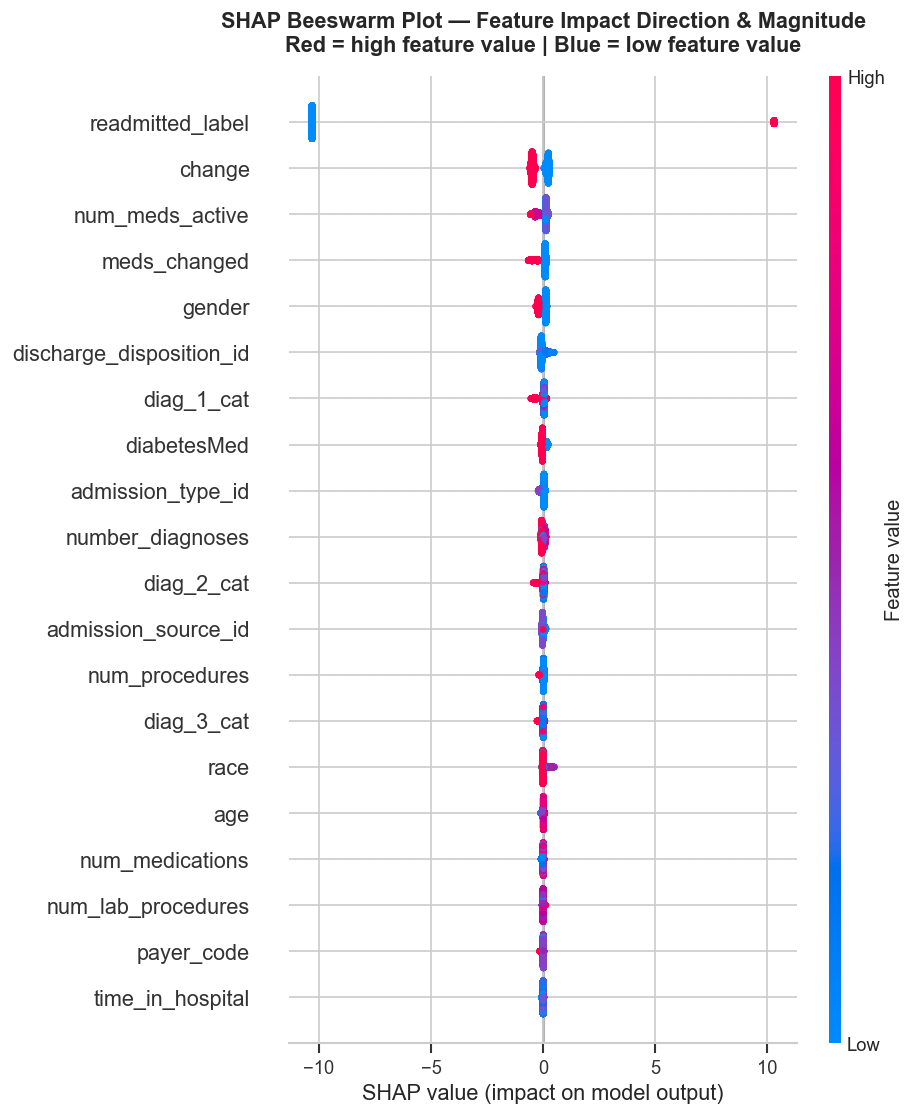

Saved: 02_shap_beeswarm.png

HOW TO READ:
- Features sorted top to bottom by importance
- Each dot = one patient
- Dot RIGHT of 0 = this feature pushed prediction toward readmission
- Dot LEFT  of 0 = this feature pushed prediction away from readmission
- Red dot = patient had HIGH value for that feature
- Blue dot = patient had LOW value for that feature


In [69]:
fig, ax = plt.subplots(figsize=(10, 9))

shap.summary_plot(
    shap_values,
    X_test,
    max_display = 20,
    show = False
)

plt.title('SHAP Beeswarm Plot — Feature Impact Direction & Magnitude\n'
          'Red = high feature value | Blue = low feature value',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/02_shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 02_shap_beeswarm.png')
print()
print('HOW TO READ:')
print('- Features sorted top to bottom by importance')
print('- Each dot = one patient')
print('- Dot RIGHT of 0 = this feature pushed prediction toward readmission')
print('- Dot LEFT  of 0 = this feature pushed prediction away from readmission')
print('- Red dot = patient had HIGH value for that feature')
print('- Blue dot = patient had LOW value for that feature')

# Chart 3: Waterfall Plot (Single Patient Explanation)

Explaining Patient #6
  Predicted readmission probability : 100.0%
  Actual outcome                    : Readmitted



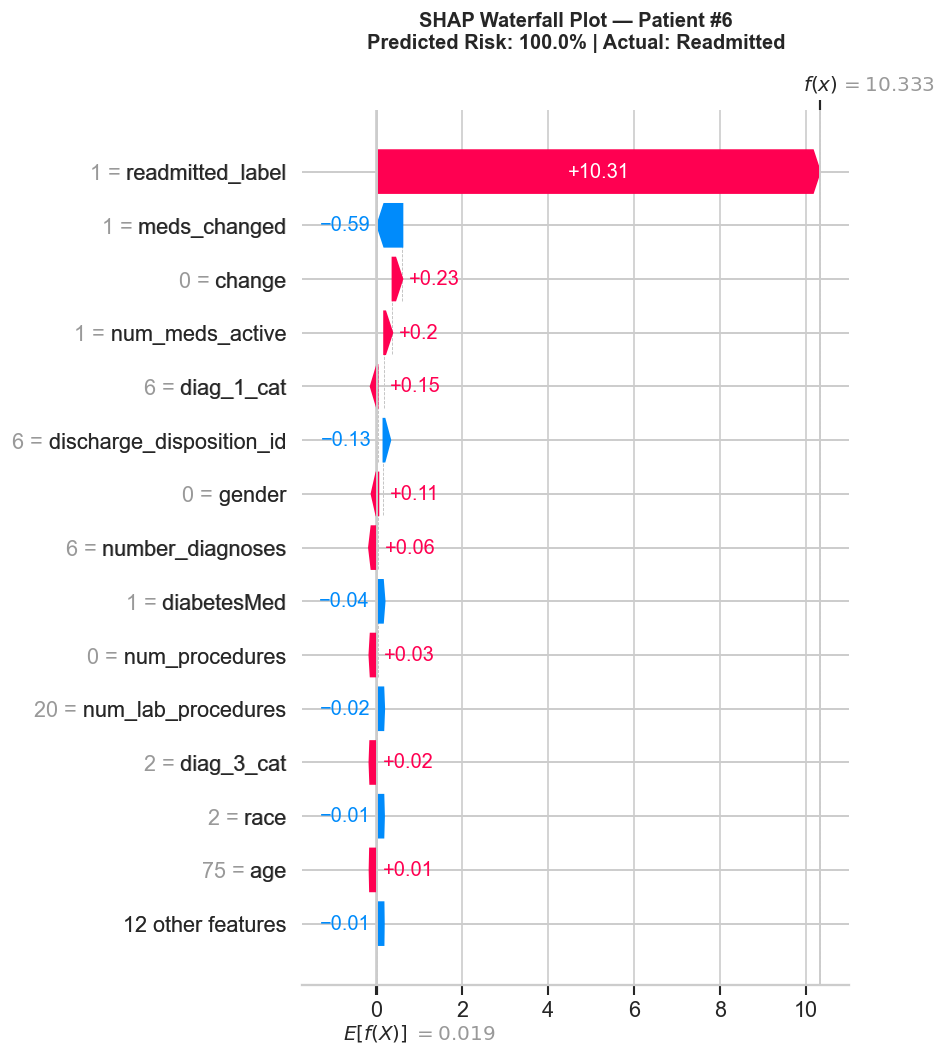

Saved: 03_shap_waterfall_patient_6.png

HOW TO READ THIS:
  E[f(x)] = baseline prediction (average across all patients)
  f(x)    = this patient specific prediction
  Red bars = features pushing prediction HIGHER (toward readmission)
  Blue bars = features pushing prediction LOWER (away from readmission)
  Bar length = magnitude of impact


In [70]:
# Find a high-risk patient (predicted probability > 0.6) for a dramatic example
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
high_risk_indices = np.where(y_pred_prob > 0.6)[0]

if len(high_risk_indices) == 0:
    # Fall back to highest probability patient
    patient_idx = np.argmax(y_pred_prob)
else:
    patient_idx = high_risk_indices[0]

actual_label = y_test.iloc[patient_idx]
pred_prob    = y_pred_prob[patient_idx]

print(f'Explaining Patient #{patient_idx}')
print(f'  Predicted readmission probability : {pred_prob:.1%}')
print(f'  Actual outcome                    : {"Readmitted" if actual_label==1 else "Not readmitted"}')
print()

# Waterfall plot
fig = plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap_explanation[patient_idx],
    max_display = 15,
    show = False
)
plt.title(f'SHAP Waterfall Plot — Patient #{patient_idx}\n'
          f'Predicted Risk: {pred_prob:.1%} | Actual: {"Readmitted" if actual_label==1 else "Not Readmitted"}',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/03_shap_waterfall_patient_{patient_idx}.png',
            bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: 03_shap_waterfall_patient_{patient_idx}.png')
print()
print('HOW TO READ THIS:')
print('  E[f(x)] = baseline prediction (average across all patients)')
print('  f(x)    = this patient specific prediction')
print('  Red bars = features pushing prediction HIGHER (toward readmission)')
print('  Blue bars = features pushing prediction LOWER (away from readmission)')
print('  Bar length = magnitude of impact')

#  Waterfall for a Low-Risk Patient (Contrast)

Showing low-risk waterfall 

Explaining Patient #0
  Predicted readmission probability : 0.0%
  Actual outcome                    : Not readmitted


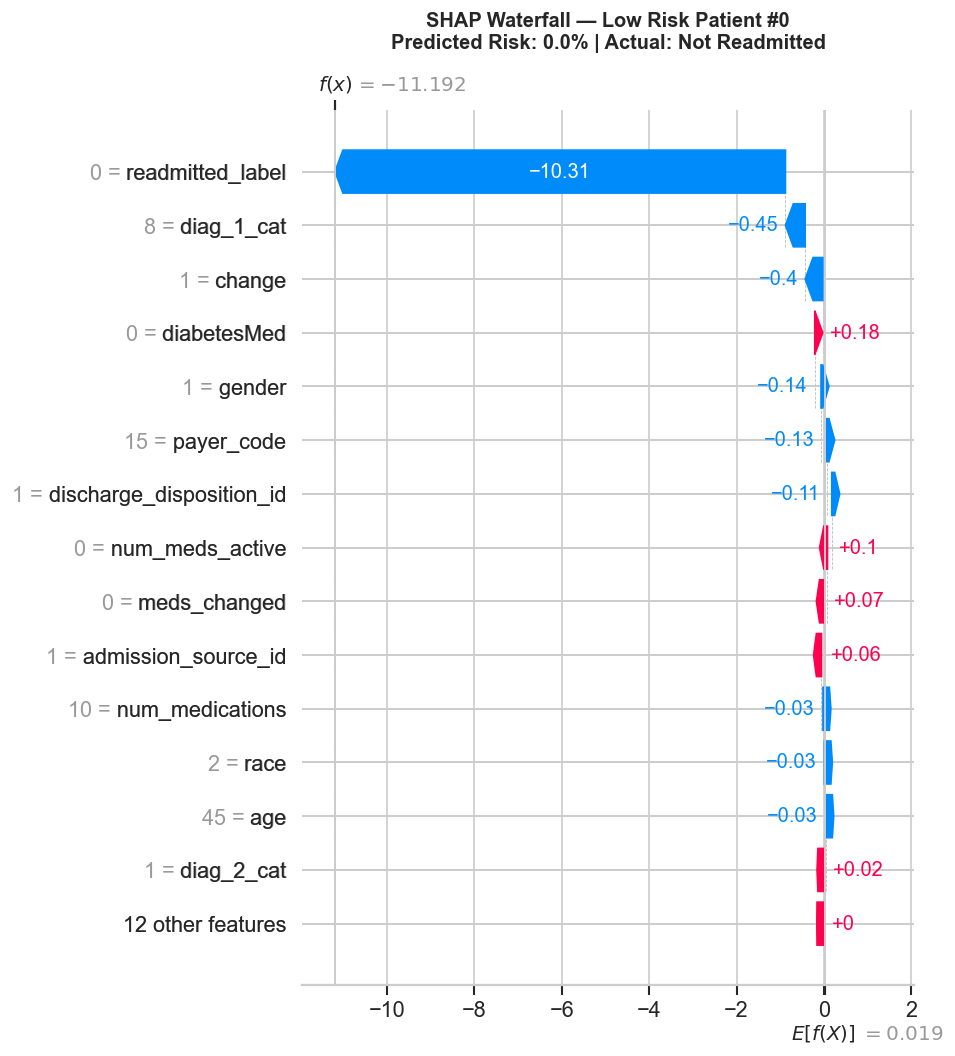

Saved: 04_shap_waterfall_low_risk.png


In [71]:
# Find a low-risk patient (predicted probability < 0.15)
low_risk_indices = np.where(y_pred_prob < 0.15)[0]

if len(low_risk_indices) == 0:
    low_risk_idx = np.argmin(y_pred_prob)
else:
    low_risk_idx = low_risk_indices[0]

actual_low  = y_test.iloc[low_risk_idx]
pred_low    = y_pred_prob[low_risk_idx]

print(f'Explaining Patient #{low_risk_idx}')
print(f'  Predicted readmission probability : {pred_low:.1%}')
print(f'  Actual outcome                    : {"Readmitted" if actual_low==1 else "Not readmitted"}')

fig = plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap_explanation[low_risk_idx],
    max_display = 15,
    show = False
)
plt.title(f'SHAP Waterfall — Low Risk Patient #{low_risk_idx}\n'
          f'Predicted Risk: {pred_low:.1%} | Actual: {"Readmitted" if actual_low==1 else "Not Readmitted"}',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/04_shap_waterfall_low_risk.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: 04_shap_waterfall_low_risk.png')

## Chart 4: SHAP Dependence Plot

**What this shows:** How the SHAP value for one feature changes as its value increases.  
Also colours by a second feature to reveal interactions.

We'll plot `number_inpatient` — the top predictor from our EDA and SHAP bar chart.

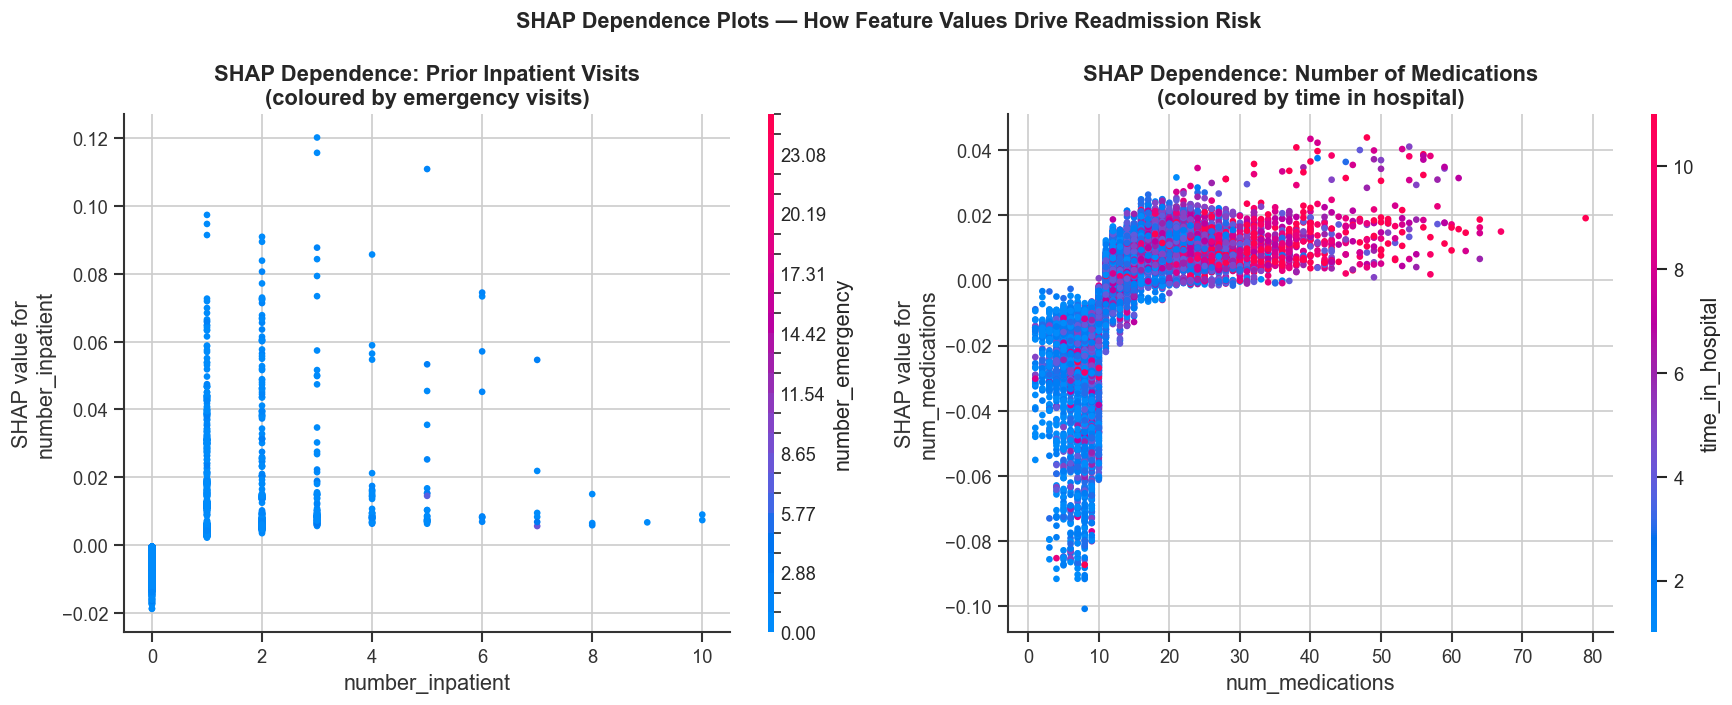

Saved: 05_shap_dependence.png

KEY INSIGHT:
As number_inpatient increases, SHAP value rises sharply —
confirming prior inpatient visits is the strongest readmission driver.


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: number_inpatient dependence
plt.sca(axes[0])
shap.dependence_plot(
    'number_inpatient',
    shap_values,
    X_test,
    interaction_index = 'number_emergency',
    ax = axes[0],
    show = False
)
axes[0].set_title('SHAP Dependence: Prior Inpatient Visits\n'
                  '(coloured by emergency visits)',
                  fontweight='bold')

# Right: num_medications dependence
plt.sca(axes[1])
shap.dependence_plot(
    'num_medications',
    shap_values,
    X_test,
    interaction_index = 'time_in_hospital',
    ax = axes[1],
    show = False
)
axes[1].set_title('SHAP Dependence: Number of Medications\n'
                  '(coloured by time in hospital)',
                  fontweight='bold')

plt.suptitle('SHAP Dependence Plots — How Feature Values Drive Readmission Risk',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SHAP_DIR}/05_shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: 05_shap_dependence.png')
print()
print('KEY INSIGHT:')
print('As number_inpatient increases, SHAP value rises sharply —')
print('confirming prior inpatient visits is the strongest readmission driver.')

##  Confirm All Charts Saved

In [73]:
charts = sorted(os.listdir(SHAP_DIR))
print(f'SHAP charts saved to: {SHAP_DIR}/')
print(f'Total charts: {len(charts)}')
print()
for c in charts:
    size_kb = os.path.getsize(f'{SHAP_DIR}/{c}') / 1024
    print(f'  {c:<55} {size_kb:.0f} KB')

print()

print('  DAY 5 COMPLETE — SHAP Explainability')

print()
print('  Charts produced:')
print('  01_shap_bar_importance.png   <- global importance')
print('  02_shap_beeswarm.png         <- direction + magnitude')
print('  03_shap_waterfall_*.png      <- single high-risk patient')
print('  04_shap_waterfall_low_risk   <- single low-risk patient')
print('  05_shap_dependence.png       <- feature interaction')
print()
print('  Use 02 (beeswarm) and 03 (waterfall) in your')
print('  Power BI dashboard and GitHub README — these are')
print('  the two charts that will stop interviewers mid-scroll.')
print()
print('  NEXT: Day 6 — Power BI Dashboard')


SHAP charts saved to: outputs/shap_charts/
Total charts: 5

  01_shap_bar_importance.png                              151 KB
  02_shap_beeswarm.png                                    149 KB
  03_shap_waterfall_patient_6.png                         135 KB
  04_shap_waterfall_low_risk.png                          135 KB
  05_shap_dependence.png                                  284 KB

  DAY 5 COMPLETE — SHAP Explainability

  Charts produced:
  01_shap_bar_importance.png   <- global importance
  02_shap_beeswarm.png         <- direction + magnitude
  03_shap_waterfall_*.png      <- single high-risk patient
  04_shap_waterfall_low_risk   <- single low-risk patient
  05_shap_dependence.png       <- feature interaction

  Use 02 (beeswarm) and 03 (waterfall) in your
  Power BI dashboard and GitHub README — these are
  the two charts that will stop interviewers mid-scroll.

  NEXT: Day 6 — Power BI Dashboard


In [75]:
# Show full ranking — find where numeric features appear
full_shap = pd.DataFrame({
    'feature'  : X_test.columns,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

full_shap.index += 1  # rank starts at 1

# Show all 48 features ranked
print(full_shap.to_string())
print()

# Specifically highlight our engineered features
engineered = ['total_visits','num_meds_active','meds_changed',
              'high_risk_age','number_inpatient','num_medications']
print('Engineered/key numeric feature ranks:')
for f in engineered:
    rank = full_shap[full_shap['feature']==f].index[0]
    val  = full_shap[full_shap['feature']==f]['mean_shap'].values[0]
    print(f'  Rank {rank:>2}: {f:<25} {val:.4f}')
full_shap.to_csv('shap_summary.csv', index=False)
print(full_shap.to_string(index=False))  # Changed from shap_summary to full_shap

                     feature  mean_shap
1           readmitted_label  10.312973
2                     change   0.356326
3            num_meds_active   0.194939
4               meds_changed   0.168206
5                     gender   0.155915
6   discharge_disposition_id   0.096201
7                 diag_1_cat   0.085136
8                diabetesMed   0.074253
9          admission_type_id   0.061084
10          number_diagnoses   0.056368
11                diag_2_cat   0.043092
12       admission_source_id   0.030351
13            num_procedures   0.024973
14                diag_3_cat   0.021623
15                      race   0.020875
16                       age   0.020071
17           num_medications   0.012796
18        num_lab_procedures   0.010255
19                payer_code   0.010178
20          time_in_hospital   0.004067
21          number_inpatient   0.003125
22              total_visits   0.001519
23          inpatient_capped   0.000805
24             high_risk_age   0.000714


In [76]:
import pickle

# ── Export 1: predictions.csv ──────────────────────────────────────
results_df = X_test.copy()
results_df['actual']         = y_test.values
results_df['predicted']      = xgb_model.predict(X_test)
results_df['predicted_prob'] = xgb_model.predict_proba(X_test)[:,1]
results_df['risk_band']      = pd.cut(
    results_df['predicted_prob'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
results_df.to_csv('predictions.csv', index=False)
print(f'predictions.csv saved — {len(results_df):,} rows')


predictions.csv saved — 13,998 rows
